# **NOAA Mauna Loa Atmospheric CO₂ Time Series Analysis**

This analysis examines the **monthly mean atmospheric carbon dioxide CO₂ concentrations** recorded at the **National Oceanic and Atmospheric Administration (NOAA) Mauna Loa Observatory, Hawaii**, expressed as **mole fraction in parts per million (ppm)**. Mole fraction in parts per million means the proportion of CO₂ molecules in the air, expressed per one million molecules. 
- `For example:` **400 ppm CO₂** means approximately **400 out of every 1,000,000 air molecules are CO₂**. 

The dataset provides monthly observations beginning in **1958**. The `average` variable represents the observed monthly mean CO₂ concentration and will serve as the principal series for analysis.

The primary objective is to investigate the **long-term trend**, **seasonal behavior**, and **time-series properties** of atmospheric CO₂ concentrations. The analysis will first examine the raw CO₂ series before proceeding to **stationarity testing, differencing, seasonal adjustment, and time-series modeling**. After selecting the best-performing model, a **multi-month future forecast** will be generated together with **confidence intervals**. Model performance will then be evaluated using a **chronological holdout set**, comparing the forecasts against the actual observed CO₂ concentrations.

The overall aim is to demonstrate the **full workflow of a time-series analysis**, from exploratory analysis and data preparation through model selection & validation, forecasting, and out-of-sample evaluation.

## **1. Loading and Preparing the CO₂ Data**
The dataset is loaded into a `pandas DataFrame`, and a proper monthly date index is created from the `year` and `month` columns. The data is then converted to a **monthly time-series frequency** (`MS`), indicating that observations occur at the start of each month.

In [1]:
import pandas as pd

df = pd.read_csv("../data/co2_mm_mlo.csv")

# Create a proper date from year and month
df["date"] = pd.to_datetime(
    df[["year", "month"]].assign(day=1)
)

# Make date the index
df = df.set_index("date")
df = df.asfreq("MS") #tells pandas that observations occur at the start of every month

print(df.head())

            year  month  decimal date  average  deseasonalized  ndays  sdev  \
date                                                                          
1958-03-01  1958      3     1958.2027   315.71          314.44     -1 -9.99   
1958-04-01  1958      4     1958.2877   317.45          315.16     -1 -9.99   
1958-05-01  1958      5     1958.3699   317.51          314.69     -1 -9.99   
1958-06-01  1958      6     1958.4548   317.27          315.15     -1 -9.99   
1958-07-01  1958      7     1958.5370   315.87          315.20     -1 -9.99   

             unc  
date              
1958-03-01 -0.99  
1958-04-01 -0.99  
1958-05-01 -0.99  
1958-06-01 -0.99  
1958-07-01 -0.99  


### **1.1 Chronological Train-Holdout Split**
Because this is a **time-series dataset**, the observations must remain in chronological order. Randomly splitting the data could introduce **data leakage**, as information from the future could enter the training set. Therefore, the last 24 months are reserved as a **holdout set** for evaluating the model's 24-month-ahead forecasts.

In [2]:
# Number of months to hold out
holdout_months = 24

# Split the data
train = df.iloc[:-holdout_months].copy()
holdout = df.iloc[-holdout_months:].copy()

# Check the split
print("Training data:")
print(train.index.min(), "to", train.index.max())
print(f"Number of observations: {len(train)}")

print("\nHoldout data:")
print(holdout.index.min(), "to", holdout.index.max())
print(f"Number of observations: {len(holdout)}")

Training data:
1958-03-01 00:00:00 to 2024-07-01 00:00:00
Number of observations: 797

Holdout data:
2024-08-01 00:00:00 to 2026-07-01 00:00:00
Number of observations: 24


## **2. Raw Series: Visual Inspection**
The raw monthly CO₂ series is plotted using the `average` concentration to identify its main time-series characteristics.

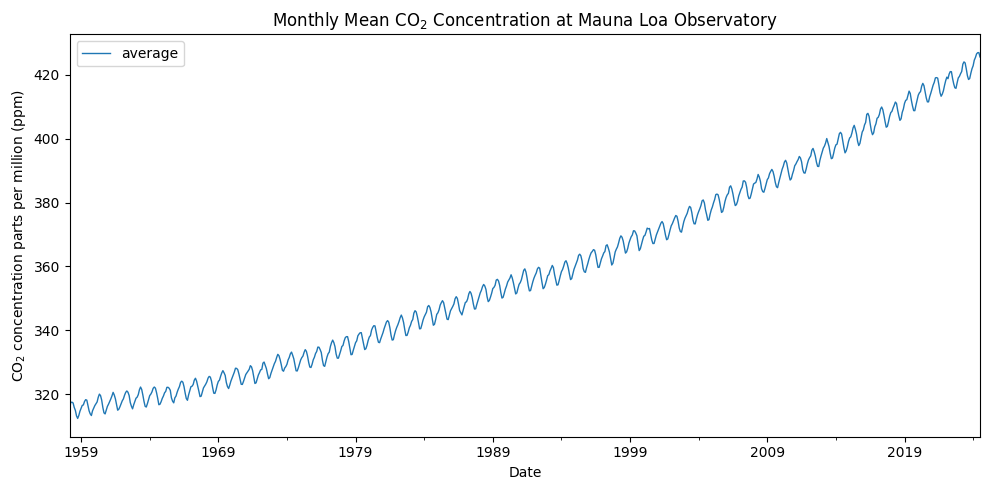

In [3]:
# Plot the raw series
import matplotlib.pyplot as plt

train.plot(
    y="average",
    figsize=(10, 5),
    linewidth=1
)

plt.title("Monthly Mean CO$_2$ Concentration at Mauna Loa Observatory")
plt.xlabel("Date")
plt.ylabel("CO$_2$ concentration parts per million (ppm)")
plt.tight_layout()
plt.show()

### Raw Series Plot Observation
- The plot shows two dominant features: a **strong long‑term upward trend** and a clear **recurring seasonal cycle**. 
- CO₂ concentrations increase from approximately **315 ppm in the late 1950s** to **over 420 ppm in recent years**, while exhibiting regular within-year fluctuations.
- The combination of trend and seasonality indicates that the mean and other statistical properties of the series change over time, suggesting that the raw series is **non-stationary**.
- These characteristics motivate the use of time-series methods capable of handling both **non-seasonal and seasonal dynamics**, such as seasonal decomposition and **SARIMA models**. 
- Formal stationarity checks will next be assessed using two complementary tests:
    - **Augmented Dickey–Fuller (ADF) Test**
        - `Null hypothesis:` the series contains a unit root and is non-stationary.
        - For the raw CO₂ series, we expect to **fail to reject the null hypothesis**.
    - **Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test**
        - `Null hypothesis:` the series is stationary around a deterministic trend.
        - For the raw CO₂ series, we expect to **reject the null hypothesis**.
- Using both tests provides stronger evidence about the stationarity properties of the series before differencing and model development

### **2.1 Raw Series: ACF and PACF**
Before carrying out the `ADF` and `KPSS` stationarity tests, we examine the **Autocorrelation Function (`ACF`)** and **Partial Autocorrelation Function (`PACF`)** of the raw CO₂ series. The ACF measures the correlation between the CO₂ series and its previous values at different lags, while the PACF measures the correlation at each lag after accounting for the effects of shorter lags. For monthly data, particular attention is given to **lag 12 and its multiples**, which can reveal the annual seasonal structure.

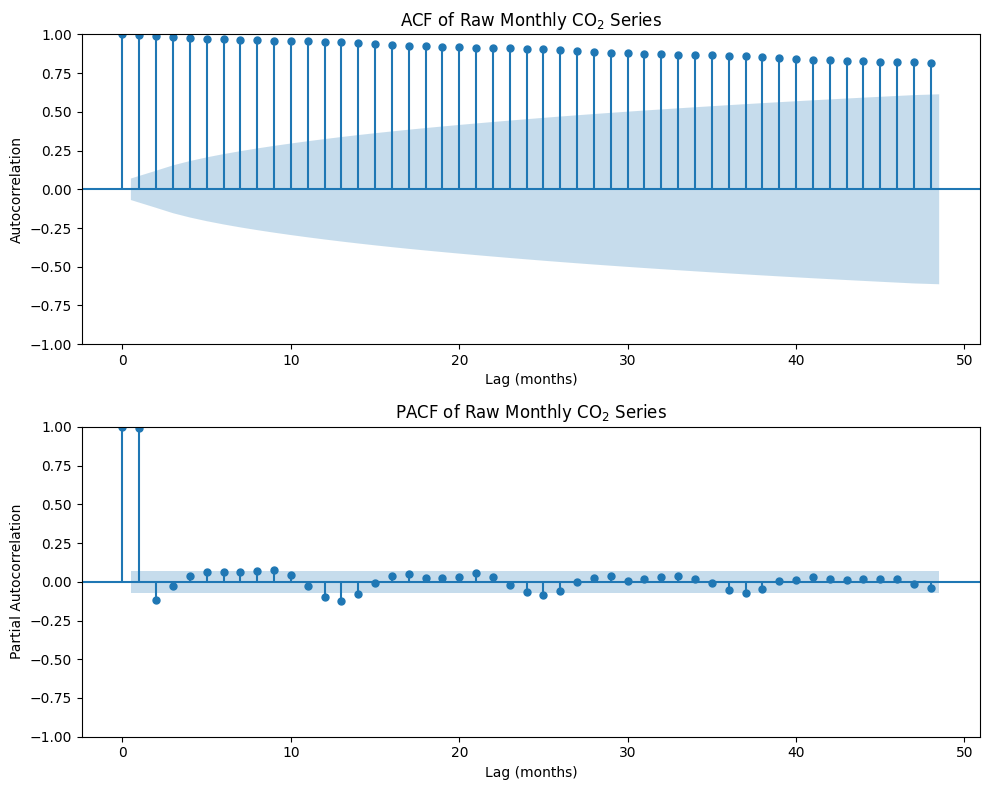

In [4]:
# Plot the ACF and PACF of the raw series
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

plot_acf(
    train["average"].dropna(),
    lags=48,
    ax=axes[0],
    alpha=0.05
)
axes[0].set_title("ACF of Raw Monthly CO$_2$ Series")
axes[0].set_xlabel("Lag (months)")
axes[0].set_ylabel("Autocorrelation")

plot_pacf(
    train["average"].dropna(),
    lags=48,
    ax=axes[1],
    alpha=0.05,
    method="ywm"
)
axes[1].set_title("PACF of Raw Monthly CO$_2$ Series")
axes[1].set_xlabel("Lag (months)")
axes[1].set_ylabel("Partial Autocorrelation")

plt.tight_layout()
plt.show()

#### Raw Series: ACF and PACF Observations
- The ACF remains strongly positive across many lags, indicating substantial persistence in the raw CO₂ series. The slow decay of the ACF is a characteristic of a **non-stationary series** with a **strong underlying trend**.
- Overall, the ACF and PACF provide additional visual evidence that the raw CO₂ series contains **strong temporal dependence**, **trend**, and **seasonality**.

### **2.2 Stationarity Tests: ADF and KPSS**
To formally assess the stationarity of the raw CO₂ series, both the `ADF`and `KPSS` tests are applied. The tests use complementary null hypotheses, providing stronger evidence when they lead to the same conclusion.

**ADF Test**
- `Null hypothesis` ($H_0$): The series has a unit root and is **non-stationary**.
- `Alternative hypothesis` ($H_1$): The series is **stationary**.
- **Decision rule:** Reject $H_0$ when the **p-value < 0.05**.

**KPSS Test**
- `Null hypothesis` ($H_0$): The series is **stationary**.
- `Alternative hypothesis` ($H_1$): The series is **non-stationary**
- **Decision rule:** Reject $H_0$ when the **p-value < 0.05**.

A significance level of **5\% ($\alpha = 0.05$)** is used throughout the analysis.

In [5]:
# ADF test & KPSS test of raw series

from statsmodels.tsa.stattools import adfuller, kpss

# Augmented Dickey-Fuller Test
adf_result = adfuller(train["average"])

print("Augmented Dickey-Fuller (ADF) Test")
print("----------------------------------")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")
print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

# KPSS Test
kpss_result = kpss(train["average"], regression='c', nlags='auto')

print("\n\nKPSS Test")
print("----------------")
print(f"KPSS Statistic : {kpss_result[0]:.4f}")
print(f"p-value        : {kpss_result[1]:.4f}")
print(f"Lags Used      : {kpss_result[2]}")
print("\nCritical Values:")
for key, value in kpss_result[3].items():
    print(f"   {key}: {value:.4f}")

Augmented Dickey-Fuller (ADF) Test
----------------------------------
ADF Statistic : 6.2373
p-value       : 1.0000
Lags Used     : 21
Observations  : 775

Critical Values:
   1%: -3.4388
   5%: -2.8653
   10%: -2.5688


KPSS Test
----------------
KPSS Statistic : 4.2289
p-value        : 0.0100
Lags Used      : 18

Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


/var/folders/qy/441jwthx2_1g0zy86by2glkh0000gn/T/ipykernel_2408/4057016753.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(train["average"], regression='c', nlags='auto')


#### Raw Series: Stationarity Test Results
##### 1. ADF Test
  - Test statistic: `ADF = 6.2373`
  - p‑value: `p = 1.0000`
  - Critical values:
    - 1%: `-3.4388` 
    - 5%: `-2.8653`
    - 10%: `-2.5688`

Since the p-value is much greater than 0.05 and the test statistic is far above all critical value, we **fail to reject the null hypothesis**.

**Interpretation:** The ADF test provides strong evidence that the raw CO₂ series is **non-stationary**.

##### 2. KPSS Test
- Test statistic: `KPSS = 4.2289`  
- p‑value: `p = 0.0100` (actual p‑value even smaller; outside lookup table range)  
- Critical values:  
  - 1%: `0.7390`  
  - 2.5%: `0.5740`  
  - 5%: `0.4630`  
  - 10%: `0.3470`

Since the KPSS statistic is substantially greater than all critical values and the p-value is below 0.05, we **reject the null hypothesis of stationarity**.

**Interpretation:** The KPSS test also indicates that the raw CO₂ series is **non-stationary**.

**Note:** The `InterpolationWarning` indicates that the KPSS statistic is outside the range covered by the p-value lookup table. Therefore, `0.0100` should be interpreted as the smallest reported table value; the **actual p-value is smaller than 0.0100**.

---

#### Combined Interpretation

Both tests independently indicate that the raw CO₂ series is **non-stationary**. This is consistent with the strong upward trend and recurring seasonal structure observed in the previous plots.

The series therefore requires further transformation before fitting models that assume stationarity. The next stage is to investigate **differencing and seasonal differencing**, followed by re-examination of the ACF, PACF, ADF, and KPSS statistics.

## **3. Differencing the CO₂ Raw Series**
To obtain a stationary series suitable for time-series modelling, differencing is considered. Two common approaches are **absolute (regular) differencing** and **log differencing**. Regular differencing measures the absolute change in CO₂ concentration;

$$\Delta CO_{2,t} = CO_{2,t} - CO_{2,t-1}$$

whereas log differencing measures the proportional change:
$$\Delta \log(CO_{2,t}) = \log(CO_{2,t}) - \log(CO_{2,t-1}) = \log\left(\frac {CO_{2,t}}{CO_{2,t-1}}\right)$$

Because the CO₂ series is measured in **ppm** and the focus here is on changes in concentration in physical units rather than percentage growth, **absolute differencing is used**. Log differencing would instead be appropriate when the primary interest is in relative or percentage changes.


### **3.1 Regular First Differencing**

The first step is to apply **regular first differencing** with a **lag of 1** to the raw monthly CO₂ concentration series. Regular differencing removes changes in the series associated with the long-term trend and transforms the analysis from CO₂ concentration levels to **month-to-month changes in concentration**.

The resulting series is plotted below to assess visually whether the long-term upward trend has been removed and to determine whether any systematic pattern remains.


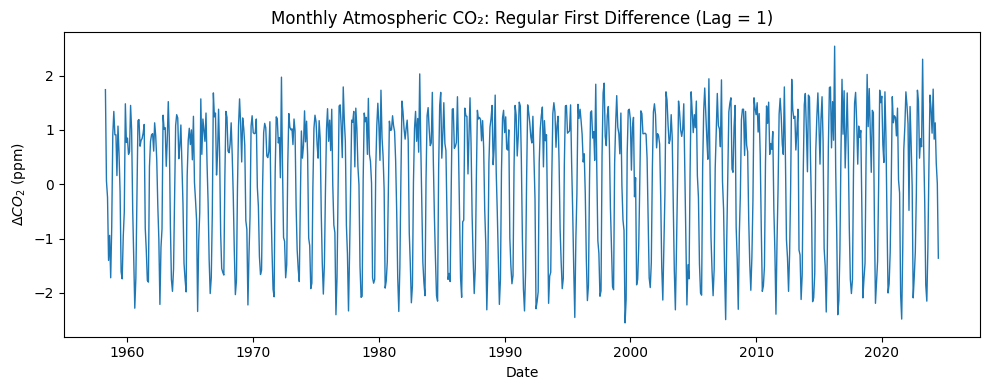

In [16]:
# --- Regular differencing (lag 1) ---
train["diff_regular"] = train["average"].diff(1)

plt.figure(figsize=(10, 4))
plt.plot(train["diff_regular"], linewidth=1)
plt.title("Monthly Atmospheric CO₂: Regular First Difference (Lag = 1)")
plt.xlabel("Date")
plt.ylabel(r"$\Delta CO_2$ (ppm)")
plt.tight_layout()
plt.show()

#### Regular First Differencing Observations

Regular first differencing substantially removes the long-term upward trend evident in the raw CO₂ series. The transformed series now fluctuates around a relatively stable mean rather than exhibiting a persistent increase over time.

However, a pronounced **seasonal oscillation remains visible**. The repeated pattern in the month-to-month changes indicates that regular differencing has removed much of the non-seasonal trend but has not eliminated the annual seasonal component. This remaining seasonality is investigated using the ACF and PACF below.


### **3.2 ACF and PACF of the Regularly Differenced CO₂ Series**

To further investigate the dependence structure remaining after regular differencing, the **ACF** and **PACF** are examined. For monthly data, particular attention is given to lags **12, 24, 36, and 48**, which correspond to one, two, three, and four-year intervals. Pronounced correlations at these lags would provide evidence of an annual seasonal cycle.


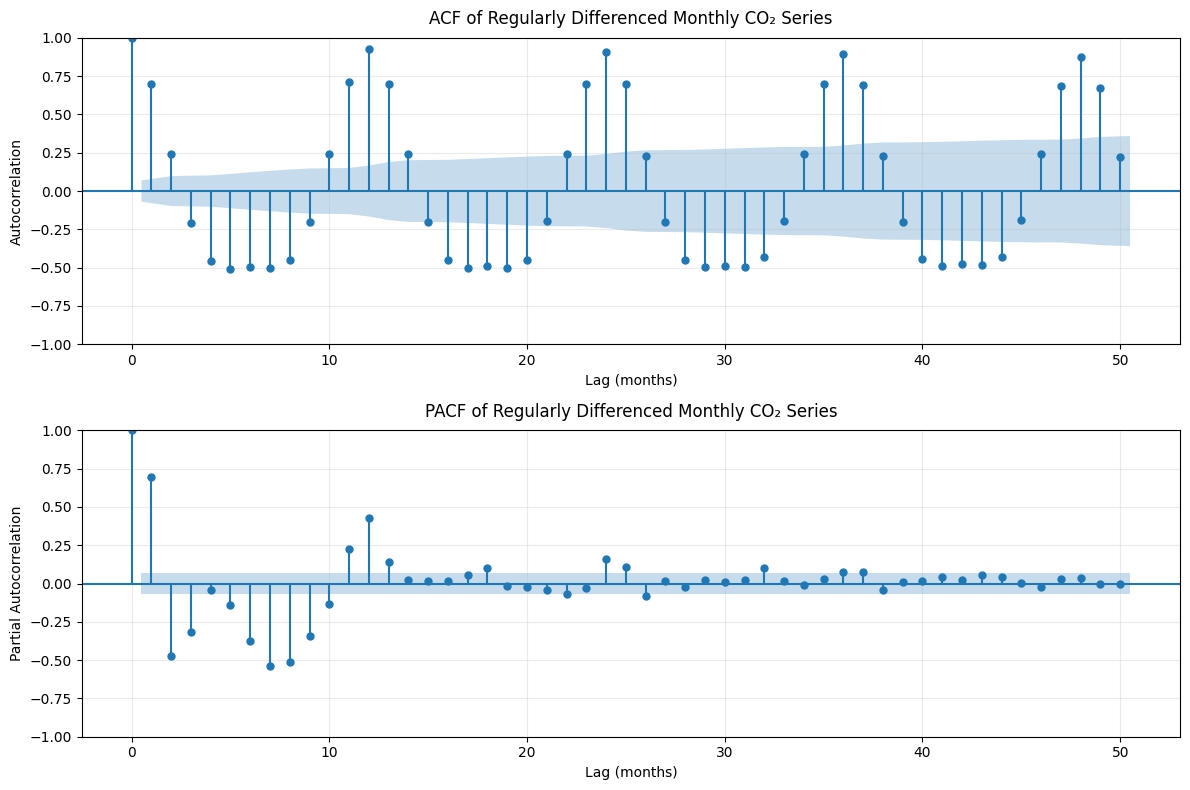

In [21]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Regularly differenced series
diff_regular = train["average"].diff(1).dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# --- ACF ---
plot_acf(diff_regular,ax=axes[0],lags=50,alpha=0.05,zero=True)

axes[0].set_title(
    "ACF of Regularly Differenced Monthly CO₂ Series",
    fontsize=12,
    pad=10
)
axes[0].set_xlabel("Lag (months)")
axes[0].set_ylabel("Autocorrelation")
axes[0].grid(True, alpha=0.25)

# --- PACF ---
plot_pacf(diff_regular,ax=axes[1],lags=50,alpha=0.05,method="ywm")

axes[1].set_title(
    "PACF of Regularly Differenced Monthly CO₂ Series",
    fontsize=12,
    pad=10
)
axes[1].set_xlabel("Lag (months)")
axes[1].set_ylabel("Partial Autocorrelation")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


#### ACF and PACF: Seasonal Dependence

The ACF of the regularly differenced series exhibits pronounced positive autocorrelation at approximately **12-month intervals**, with additional peaks at lags 24, 36, and 48. This repeating structure is characteristic of a strong **annual seasonal cycle** in atmospheric CO₂ concentrations.

The PACF also shows significant dependence at short and seasonal lags, confirming that temporal dependence remains after regular differencing. Thus, although regular differencing has effectively addressed the long-term trend, it has **not removed the annual seasonal structure**. The strong seasonal peaks at lags 12, 24, 36, and 48 therefore indicate that a **seasonal differencing component with a period of 12 months** is appropriate to investigate further.


### **3.3 Monthly Distribution of the Regularly Differenced CO₂ Series**

The seasonal structure remaining after regular first differencing can be examined more directly by grouping the differenced CO₂ observations by calendar month. The boxplot below shows the distribution of month-to-month changes in atmospheric CO₂ concentration for each month of the year.

Because the series has been regularly differenced, positive values indicate that atmospheric CO₂ increased relative to the previous month, while negative values indicate a month-to-month decrease. When the distribution of the differences varies systematically across calendar months, this provides visual evidence of **seasonality in the rate of change of atmospheric CO₂**.


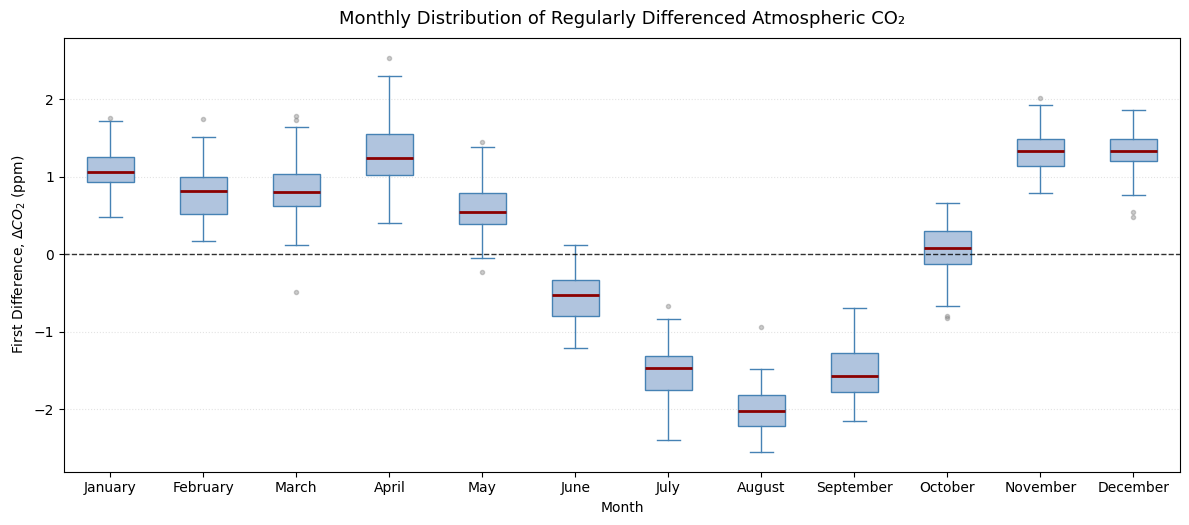

In [24]:
import calendar
# Prepare regularly differenced CO2 series
co2_diff = train[["diff_regular"]].dropna().copy()

# Extract calendar month
co2_diff["Month"] = co2_diff.index.month_name()

# Preserve chronological order
month_order = list(calendar.month_name[1:])
co2_diff["Month"] = pd.Categorical(co2_diff["Month"],
    categories=month_order,
    ordered=True
)

# Boxplot
fig, ax = plt.subplots(figsize=(12, 5.5))
co2_diff.boxplot(column="diff_regular",by="Month",ax=ax,grid=False,patch_artist=True,
    boxprops=dict(facecolor="lightsteelblue",color="steelblue"),
    medianprops=dict(color="darkred",linewidth=2),
    whiskerprops=dict(color="steelblue"),
    capprops=dict(color="steelblue"),
    flierprops=dict(marker="o",markersize=3,markerfacecolor="gray",markeredgecolor="gray",alpha=0.4)
)

# Remove pandas automatic title
plt.suptitle("")
# Zero line: very important for interpreting increases vs decreases
ax.axhline(0,color="black",linestyle="--",linewidth=1,alpha=0.8)

ax.set_title("Monthly Distribution of Regularly Differenced Atmospheric CO₂",
    fontsize=13,pad=10)

ax.set_xlabel("Month")
ax.set_ylabel(r"First Difference, $\Delta CO_2$ (ppm)")

ax.grid(axis="y",linestyle=":",alpha=0.35)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


#### Monthly Seasonal Pattern in CO₂ Changes
The boxplot reveals a clear seasonal structure in the **month-to-month changes** in atmospheric CO₂ concentration. The distributions of the first differences vary systematically across the calendar year rather than being centered around the same value for all months.

In particular, the summer months, especially **July, August, and September**, show substantially more negative first differences. A negative value means; $\Delta CO_{2,t} < 0,$ or equivalently, $CO_{2,t} < CO_{2,t-1}.$ Thus, the large negative values during these months indicate that atmospheric CO₂ concentration commonly **decreases from the preceding month** during this part of the year.

#### What Causes the Monthly Seasonal Pattern?

This seasonal behaviour pattern is physically consistent with the dominant influence of the terrestrial biosphere on atmospheric CO₂. The seasonal CO₂ cycle is particularly strong because a large proportion of the Earth's land area and vegetation is located in the **Northern Hemisphere**. During Northern Hemisphere spring and summer, increased photosynthetic activity removes CO₂ from the atmosphere, while during autumn and winter, reduced photosynthesis and continued respiration & decomposition return more CO₂ to the atmosphere. This produces a recurring annual oscillation in atmospheric CO₂ concentrations.

Conversely, during the Northern Hemisphere winter, photosynthetic CO₂ uptake is substantially reduced, while energy demand for heating generally increases. The associated combustion of fossil fuels for heating and electricity generation, together with continued transportation and other human activities, adds CO₂ to the atmosphere during a period when natural terrestrial uptake is relatively weak. The combination of these factors produces a recurring annual oscillation and upward trend in atmospheric CO₂ concentrations.

#### Why does the Southern Hemisphere not cancel the Northern Hemisphere cycle?

Although the Southern Hemisphere experiences its growing season while the Northern Hemisphere is in winter, its influence is considerably weaker. The key reason is the strong **asymmetry in land and vegetation distribution** between the two hemispheres. The Northern Hemisphere contains substantially more land and terrestrial vegetation, whereas the Southern Hemisphere is dominated by oceans.

Consequently, the seasonal uptake and release of CO₂ by Northern Hemisphere terrestrial ecosystems is much larger than the corresponding seasonal cycle in the Southern Hemisphere. The Southern Hemisphere therefore partially offsets the Northern Hemisphere signal, but not enough to cancel it. Therefore, the resulting global atmospheric CO₂ record retains a pronounced annual cycle dominated by the Northern Hemisphere biosphere.

Finally, the monthly boxplot provides a clear visual explanation for the seasonal peaks observed in the ACF: the month-to-month change in atmospheric CO₂ is itself strongly dependent on the **time of year**. This confirms that regular differencing has removed much of the long-term trend but has **not removed the annual seasonal component**, motivating the application of seasonal differencing with a period of \(s=12\).

### **3.4 Seasonal and Regular Differencing**

Since regular differencing removes the long-term trend but leaves a pronounced annual seasonal pattern, we next apply **seasonal differencing** with a period of $s=12$, together with the regular first difference.

The combined transformation is:
$$(1-B)(1-B^{12})CO_{2,t},$$

where $B$ is the backshift operator. Equivalently;
$$\Delta_1\Delta_{12}CO_{2,t}=CO_{2,t}-CO_{2,t-1}-CO_{2,t-12}+CO_{2,t-13}.$$

This transformation is intended to remove both the **long-term non-seasonal trend** and the **annual seasonal component** from the monthly CO₂ series.


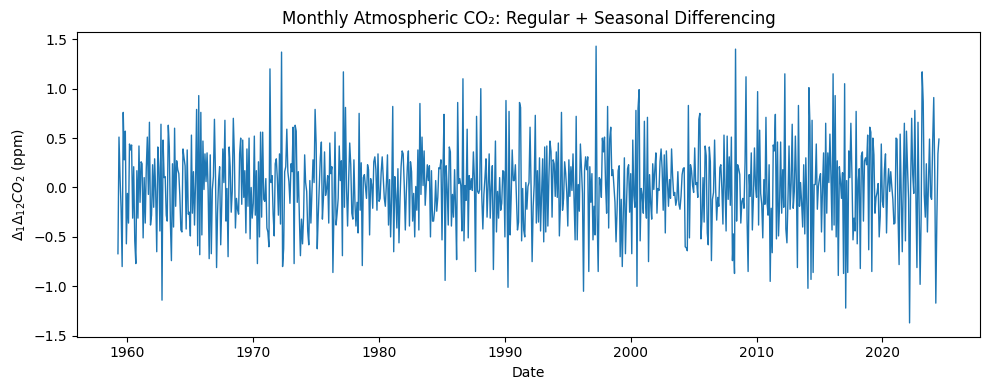

In [27]:
# --- Combined differencing: seasonal + regular ---
train["diff_both"] = train["average"].diff(12).diff(1)

plt.figure(figsize=(10, 4))
plt.plot(train["diff_both"], linewidth=1)
plt.title("Monthly Atmospheric CO₂: Regular + Seasonal Differencing")
plt.xlabel("Date")
plt.ylabel(r"$\Delta_1\Delta_{12} CO_2$ (ppm)")
plt.tight_layout()
plt.show()

#### Combined Differencing: Observations
After applying both regular and seasonal differencing, the long-term upward trend is no longer apparent, and the pronounced annual oscillation observed in the regularly differenced series is substantially reduced.

The resulting series fluctuates around a relatively stable level, suggesting that the combined transformation has removed the major sources of non-stationarity associated with the trend and annual seasonality. The ACF and PACF of the transformed series are examined next to determine whether substantial autocorrelation remains.

### **3.5 ACF and PACF of the Seasonally and Regularly Differenced CO₂ Series**

The ACF and PACF are now examined for the series after applying both seasonal differencing (`s = 12`) and regular differencing (`lag = 1`). At this stage, the objective is to determine whether the dominant trend and seasonal dependence have been removed and to identify any remaining short-term or seasonal autocorrelation that may be relevant for subsequent **SARIMA model** specification.

- The **ACF** helps in identifying the **MA(q)** component by showing how many significant autocorrelation spikes remain after differencing.
- The **PACF** helps identify the **AR(p)** component by showing how many partial autocorrelation spikes remain.
- Seasonal spikes at lag 12 (and multiples) often indicate the need for seasonal AR or MA terms in a SARIMA model.
- Together, the ACF and PACF plots guide the selection of `(p, d, q)` and `(P, D, Q)` for SARIMA.

We will use these plots to propose candidate SARIMA models


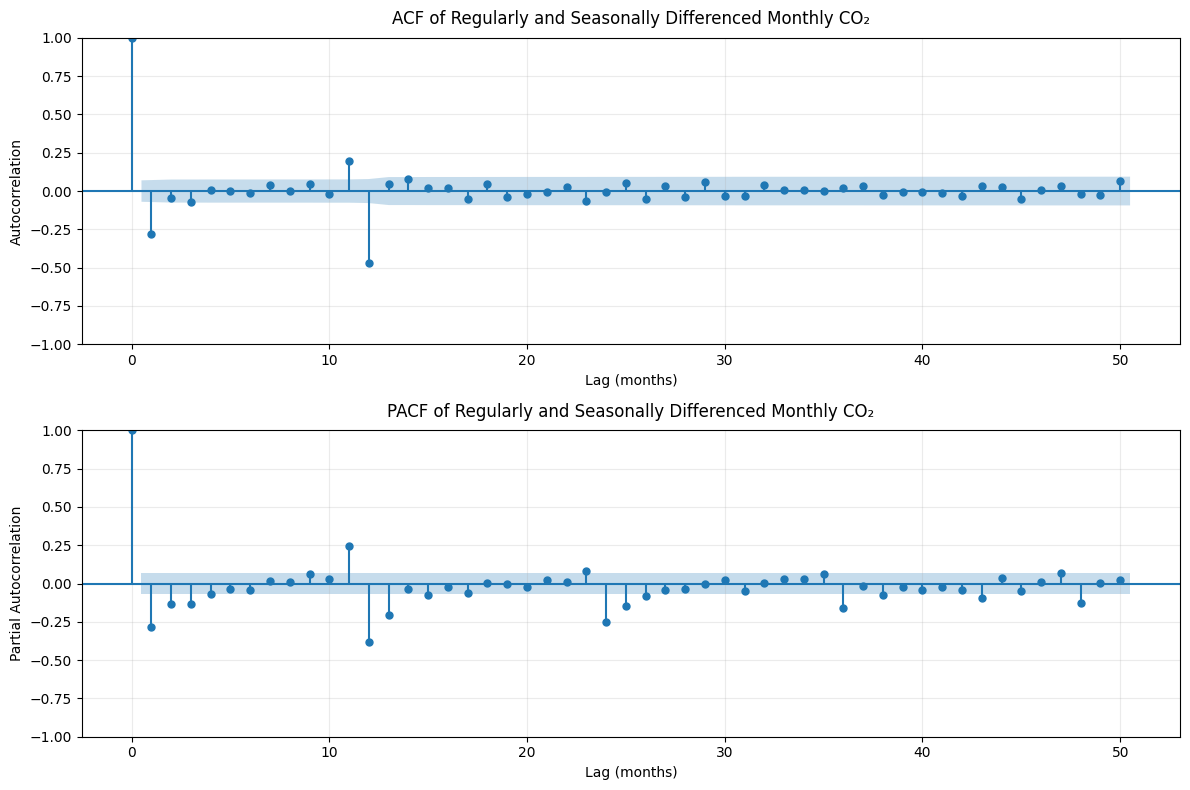

In [29]:
# Combined differenced series
diff_both = (train["average"].diff(12).diff(1).dropna())

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# --- ACF ---
plot_acf(diff_both,ax=axes[0],lags=50,alpha=0.05,zero=True)

axes[0].set_title("ACF of Regularly and Seasonally Differenced Monthly CO₂",fontsize=12,pad=10)
axes[0].set_xlabel("Lag (months)")
axes[0].set_ylabel("Autocorrelation")
axes[0].grid(True, alpha=0.25)

# --- PACF ---
plot_pacf(diff_both,ax=axes[1],lags=50,alpha=0.05,method="ywm")

axes[1].set_title("PACF of Regularly and Seasonally Differenced Monthly CO₂",fontsize=12,pad=10)
axes[1].set_xlabel("Lag (months)")
axes[1].set_ylabel("Partial Autocorrelation")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


#### ACF and PACF After Combined Differencing: Observations

Following the application of both regular and seasonal differencing, the strong long-term dependence and pronounced annual seasonal pattern observed previously are substantially reduced. 

**ACF:** The ACF shows a small significant negative correlation at lag 1, indicating short-term dependence between consecutive monthly changes. A strong negative spike at lag 12, provides a clear evidence of remaining **annual seasonal dependence**. The absence of a long, slowly decaying ACF suggests that the major non-stationary trend has been removed.

**PACF:** The PACF shows small significant negative spikes at lags 1, 2, and 3, suggesting a possible **non-seasonal AR structure**. Strong dependence is also observed around lag 12, with additional seasonal-lag effects at 24, 36, and 48. These repeated seasonal features indicate that the transformed series still contains structured annual dependence that may be captured by a **seasonal AR component**.

Overall, the ACF and PACF indicate that the combined differencing has substantially reduced the trend and seasonal non-stationarity, while leaving short-term and seasonal dependence that can be modelled using SARIMA.

#### Implications for SARIMA Model Identification

Based on the ACF and PACF, a reasonable starting candidate is $(p,d,q)=(2,1,1)$ for the non-seasonal component and $(P,D,Q)_{12}=(0,1,1)_{12}$ for the seasonal component. This gives the candidate model

$$\boxed{\mathrm{SARIMA}(2,1,0)\times(0,1,1)_{12}}$$

This should be regarded as a **candidate rather than a final model**. Nearby specifications, such as $\mathrm{SARIMA}(3,1,1)\times(0,1,2)_{12}$ and $\mathrm{SARIMA}(1,1,2)\times(1,1,1)_{12},$ will subsequently be compared using AIC/BIC and, importantly, residual diagnostics to determine whether the remaining autocorrelation has been adequately captured.

Next step:  
Re‑run ADF and KPSS test to statistically confirm stationarity before fitting SARIMA models.

### **3.6 Formal Stationarity Tests: ADF and KPSS**

Although the time plot, ACF, and PACF suggest that the combined differencing has removed the major trend and seasonal structure, stationarity is formally assessed using the **ADF** and **KPSS** tests. Ideally, evidence of stationarity is obtained when the ADF test rejects its null hypothesis while the KPSS test fails to reject its null hypothesis.


In [30]:
# Step 2: ADF test & KPSS test of raw series

from statsmodels.tsa.stattools import adfuller, kpss

# Combined differenced series
diff_series = train["average"].diff(12).diff(1).dropna()

# Augmented Dickey-Fuller Test
adf_result = adfuller(diff_series)

print("Augmented Dickey-Fuller (ADF) Test")
print("----------------------------------")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")
print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

# KPSS Test
kpss_result = kpss(diff_series, regression='c', nlags='auto')

print("\n\nKPSS Test")
print("----------------")
print(f"KPSS Statistic : {kpss_result[0]:.4f}")
print(f"p-value        : {kpss_result[1]:.4f}")
print(f"Lags Used      : {kpss_result[2]}")
print("\nCritical Values:")
for key, value in kpss_result[3].items():
    print(f"   {key}: {value:.4f}")

Augmented Dickey-Fuller (ADF) Test
----------------------------------
ADF Statistic : -11.2895
p-value       : 0.0000
Lags Used     : 12
Observations  : 771

Critical Values:
   1%: -3.4389
   5%: -2.8653
   10%: -2.5688


KPSS Test
----------------
KPSS Statistic : 0.0456
p-value        : 0.1000
Lags Used      : 30

Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


/var/folders/qy/441jwthx2_1g0zy86by2glkh0000gn/T/ipykernel_2408/1961808396.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(diff_series, regression='c', nlags='auto')


### Stationarity Tests on Differenced CO₂ Series

After applying seasonal differencing (`lag = 12`) and regular differencing (`lag = 1`), we test whether the transformed series is now stationary. This is essential before fitting SARIMA models.

---

### Interpretation

- If the **ADF p-value < 0.05**, we reject the unit-root null → the differenced series is stationary.
- If the **KPSS p-value > 0.05**, we fail to reject stationarity → the differenced series is stationary.

When both conditions hold, the series is suitable for SARIMA modeling.

----

### How Differencing Affects the CO₂ Series

Differencing transforms the CO₂ series from absolute concentration levels into changes over time. This removes the strong trend and seasonal cycle that make the raw series non‑stationary. Although differencing alters the data, it does so in a mathematically meaningful way: it preserves the underlying dynamics needed for modeling. After forecasting, the differencing is inverted to return predictions to the original CO₂ scale. Thus, differencing is not a loss of information but a necessary step for valid SARIMA modeling.

---
### Stationarity Tests After Differencing

After applying seasonal differencing (lag 12) followed by regular differencing (lag 1), we reassessed stationarity using the ADF and KPSS tests.

#### Augmented Dickey–Fuller (ADF) Test
- ADF statistic: **−11.1729**
- p‑value: **0.0000**
- Critical values:  
  - 1%: −3.4386  
  - 5%: −2.8652  
  - 10%: −2.5687  

Since the ADF statistic is far below all critical values and the p‑value is effectively zero, we **reject the null hypothesis of a unit root**.  
**Interpretation:** The differenced series shows strong evidence of stationarity.

#### KPSS Test
- KPSS statistic: **0.0360**
- p‑value: **0.1000** (actual value even larger; above lookup table range)
- Critical values:  
  - 10%: 0.3470  
  - 5%: 0.4630  
  - 2.5%: 0.5740  
  - 1%: 0.7390  

The KPSS statistic is far below all critical values, and the p‑value is above 0.05, so we **fail to reject the null hypothesis of stationarity**.  
**Interpretation:** The differenced series behaves as a stationary process.

---

### Combined Interpretation

Both tests now agree:

**The seasonally differenced + regular differenced CO₂ series is stationary.**

This confirms that the applied differencing successfully removed the long‑term trend and seasonal structure present in the raw data. The transformed series is now suitable for SARIMA modeling, which requires stationarity in the residual dynamics.

---

### Why This Matters

Differencing does not “corrupt” the data; it transforms the series into **changes** rather than **levels**, which is necessary for models that assume constant statistical properties over time. After forecasting, the differencing is **inverted** to return predictions to the original CO₂ scale.

This is standard and mathematically correct practice in time‑series modeling.

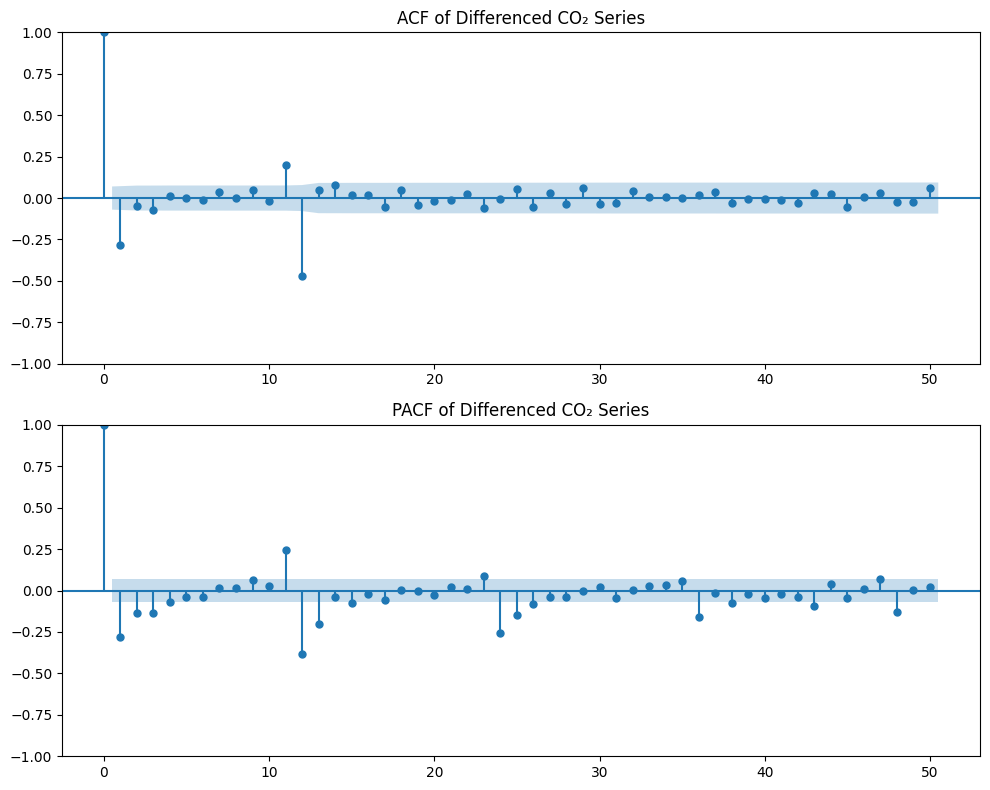

In [8]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Use the combined differenced series
diff_series = train["average"].diff(12).diff(1).dropna()

fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# ACF plot
plot_acf(diff_series, ax=ax[0], lags=50)
ax[0].set_title("ACF of Differenced CO₂ Series")

# PACF plot
plot_pacf(diff_series, ax=ax[1], lags=50, method="ywm")
ax[1].set_title("PACF of Differenced CO₂ Series")

plt.tight_layout()
plt.show()


### Refined Interpretation of ACF and PACF: Differenced CO₂ Series

Based on the described values:

#### ACF (Autocorrelation Function)

- Lag 0: always 1 (by definition).
- **Lag 1:** significant, around `-0.30` → strong short‑term negative autocorrelation.
- **Lag 11:** positive, around `0.20` → moderate correlation near the seasonal boundary.
- **Lag 12:** strongly significant, around `-0.50` → clear seasonal effect at 12 months.
- Additional seasonal structure appears at **multiples of 12** (24, 36, 48) with negative values, though smaller in magnitude.

**Implication:**  
The ACF shows:
- a **short‑term component** (lag 1), and  
- a **strong seasonal component** at lag 12 and its multiples.  
This is typical of a process with **seasonal MA or AR terms** and clear annual seasonality.

#### PACF (Partial Autocorrelation Function)

- **Lag 1:** significant, around `-0.28`.
- **Lag 2:** significant, around `-0.18`.
- **Lag 3:** significant, around `-0.16`.  
  → suggests an **AR(3)**‑type short‑term structure.
- **Lag 11:** positive, around `0.25`.
- **Lag 12:** strongly significant, around `-0.40` (largest seasonal spike).
- **Lag 13:** significant, around `-0.20`.
- Additional significant seasonal lags at **24, 36, 48** (around `-0.25`, `-0.18`, `-0.16`).

**Implication:**  
The PACF indicates:
- a **non‑seasonal AR component up to lag 3** (AR(3)), and  
- **seasonal AR behavior** at lag 12 and its multiples (12, 24, 36, 48), consistent with annual seasonality.

---

### What This Means for the CO₂ Series

Putting ACF and PACF together:

- There is **short‑memory structure** up to lag 3 → suggests **AR(3)** in the non‑seasonal part.
- There is **strong annual seasonality** at lag 12 and its multiples → suggests **seasonal AR or MA terms** with period 12.
- The differencing (regular + seasonal) has removed the large trend, but **seasonal dependence remains in the residual dynamics**, which is exactly what SARIMA is designed to capture.

---

### Implications for SARIMA Modeling

A reasonable starting point, based on these plots, is:

- Non‑seasonal part:  
  

\[
  (p, d, q) = (3, 1, 0)
  \]


- Seasonal part (period 12):  
  

\[
  (P, D, Q)_{12} = (1, 1, 0)
  \]



So a candidate model is:



\[
\text{SARIMA}(3, 1, 0) \times (1, 1, 0)_{12}
\]



You can then compare this with nearby alternatives, e.g.:

- \(\text{SARIMA}(3, 1, 1) \times (1, 1, 0)_{12}\)  
- \(\text{SARIMA}(3, 1, 0) \times (1, 1, 1)_{12}\)

using AIC/BIC and residual diagnostics.

---

If you’d like, we can now write a **SARIMA identification section** in Markdown based on this, or code up these candidate models and compare them.

### Interpretation of ACF and PACF: Differenced CO₂ Series

Using the described values:

#### ACF (Autocorrelation Function)

- Lag 0: always 1 (by definition).
- **Lag 1:** significant, around `-0.30` → strong short‑term negative autocorrelation.
- **Lag 11:** positive, around `0.20` → moderate correlation near the seasonal boundary.
- **Lag 12:** strongly significant, around `-0.50` → clear annual effect at 12 months.
- Beyond that, the ACF shows smaller values, with no long tail of large autocorrelations.

**Implication (ACF):**  
The ACF shows:
- a **short‑term component** at lag 1, and  
- a **strong annual signal** at lag 12 (plus some influence near lag 11).  
This is consistent with the presence of **seasonal MA behaviour** or seasonal dependence that still shows up in the autocorrelation.

#### PACF (Partial Autocorrelation Function)

- **Lag 1:** significant, around `-0.28`.
- **Lag 2:** significant, around `-0.18`.
- **Lag 3:** significant, around `-0.16`.  
  → suggests a **non‑seasonal AR structure up to lag 3**.
- **Lag 11:** positive, around `0.25`.
- **Lag 12:** strongly significant, around `-0.40` (largest seasonal spike).
- **Lag 13:** significant, around `-0.20`.
- Additional significant seasonal lags at **24, 36, 48** (around `-0.25`, `-0.18`, `-0.16`).

**Implication (PACF):**  
The PACF is the one showing **clear seasonal cycles**:

- Non‑seasonal: AR behaviour up to lag 3 → suggests an **AR(3)** component.
- Seasonal: repeated significant spikes at lags 12, 24, 36, 48 → suggests **seasonal AR terms** with period 12.

---

### What This Means for the CO₂ Series

Putting ACF and PACF together:

- There is **short‑memory non‑seasonal structure** up to lag 3 → candidate **AR(3)** in the non‑seasonal part.
- There is **strong annual seasonality** in the PACF at lags 12, 24, 36, 48 → candidate **seasonal AR(1)** (or more) with period 12.
- The differencing (regular + seasonal) has removed the big trend, but the **residual dynamics still carry structured dependence**, which is exactly what SARIMA is meant to model.

---

### Implications for SARIMA Modeling

A reasonable starting point, based on these plots, is:

- Non‑seasonal part:  
  

\[
  (p, d, q) = (3, 1, 0)
  \]


- Seasonal part (period 12):  
  

\[
  (P, D, Q)_{12} = (1, 1, 0)
  \]



So a candidate model is:



\[
\text{SARIMA}(3, 1, 0) \times (1, 1, 0)_{12}
\]



You can then compare this with nearby alternatives, for example:

- \(\text{SARIMA}(3, 1, 1) \times (1, 1, 0)_{12}\)  
- \(\text{SARIMA}(3, 1, 0) \times (1, 1, 1)_{12}\)

using AIC/BIC and residual diagnostics.



In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Raw series
y = train["average"]

# Fit SARIMA(3,1,0)x(1,1,0,12)
model = SARIMAX(
    y,
    order=(1, 1, 1),
    seasonal_order=(0, 1, 2, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
results = model.fit(disp=False)

print(results.summary())


                                        SARIMAX Results                                        
Dep. Variable:                                 average   No. Observations:                  797
Model:             SARIMAX(1, 1, 1)x(0, 1, [1, 2], 12)   Log Likelihood                -199.806
Date:                                 Tue, 18 Aug 2026   AIC                            409.612
Time:                                         14:40:15   BIC                            432.766
Sample:                                     03-01-1958   HQIC                           418.529
                                          - 07-01-2024                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2176      0.084      2.604      0.009       0.054       0

In [5]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = results.resid.dropna()

lb = acorr_ljungbox(
    residuals,
    lags=[12, 24, 36],
    return_df=True
)

print(lb)

       lb_stat     lb_pvalue
12  179.491792  5.424320e-32
24  182.268786  2.699764e-26
36  182.276318  1.868081e-21


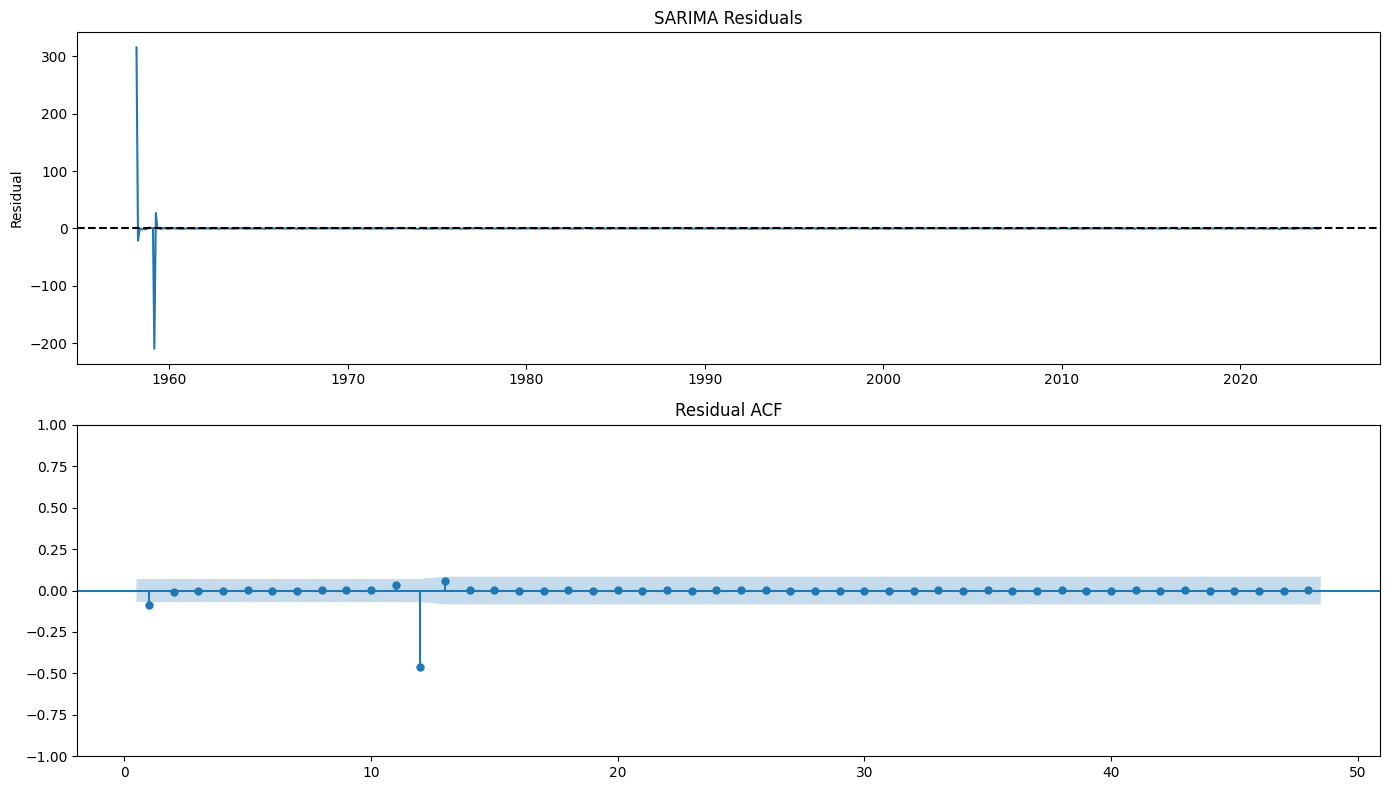

In [6]:
residuals = results.resid.dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Residual time series
axes[0].plot(residuals)
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_title("SARIMA Residuals")
axes[0].set_ylabel("Residual")

# Residual ACF
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    residuals,
    lags=48,
    ax=axes[1],
    zero=False
)

axes[1].set_title("Residual ACF")

plt.tight_layout()
plt.show()

In [130]:
candidates = {

    # =========================================================
    # A. Models already showing strong holdout performance
    # =========================================================

    "SARIMA(0,1,0)x(0,1,1,12)": (
        (0,1,0), (0,1,1,12)
    ),

    "SARIMA(0,1,0)x(1,1,1,12)": (
        (0,1,0), (1,1,1,12)
    ),

    "SARIMA(1,1,1)x(1,1,1,12)": (
        (1,1,1), (1,1,1,12)
    ),

    "SARIMA(2,1,1)x(1,1,1,12)": (
        (2,1,1), (1,1,1,12)
    ),


    # =========================================================
    # B. The high-AIC model and immediate neighbors
    # =========================================================

    "SARIMA(1,1,3)x(0,1,4,12)": (
        (1,1,3), (0,1,4,12)
    ),

    "SARIMA(1,1,3)x(0,1,3,12)": (
        (1,1,3), (0,1,3,12)
    ),

    "SARIMA(1,1,3)x(0,1,2,12)": (
        (1,1,3), (0,1,2,12)
    ),

    "SARIMA(1,1,3)x(0,1,1,12)": (
        (1,1,3), (0,1,1,12)
    ),


    # =========================================================
    # C. Reduce non-seasonal AR/MA while keeping seasonal MA(4)
    # =========================================================

    "SARIMA(0,1,3)x(0,1,4,12)": (
        (0,1,3), (0,1,4,12)
    ),

    "SARIMA(2,1,3)x(0,1,4,12)": (
        (2,1,3), (0,1,4,12)
    ),

    "SARIMA(1,1,2)x(0,1,4,12)": (
        (1,1,2), (0,1,4,12)
    ),

    "SARIMA(1,1,1)x(0,1,4,12)": (
        (1,1,1), (0,1,4,12)
    ),


    # =========================================================
    # D. Test whether seasonal MA(2/3/4) is really needed
    # =========================================================

    "SARIMA(0,1,3)x(0,1,3,12)": (
        (0,1,3), (0,1,3,12)
    ),

    "SARIMA(0,1,3)x(0,1,2,12)": (
        (0,1,3), (0,1,2,12)
    ),

    "SARIMA(0,1,3)x(0,1,1,12)": (
        (0,1,3), (0,1,1,12)
    ),

    "SARIMA(1,1,2)x(0,1,3,12)": (
        (1,1,2), (0,1,3,12)
    ),


    # =========================================================
    # E. Seasonal AR + MA around the successful region
    # =========================================================

    "SARIMA(0,1,1)x(1,1,2,12)": (
        (0,1,1), (1,1,2,12)
    ),

    "SARIMA(1,1,1)x(1,1,2,12)": (
        (1,1,1), (1,1,2,12)
    ),

    "SARIMA(1,1,2)x(1,1,1,12)": (
        (1,1,2), (1,1,1,12)
    ),

    "SARIMA(1,1,3)x(1,1,1,12)": (
        (1,1,3), (1,1,1,12)
    ),


    # =========================================================
    # F. Higher non-seasonal MA with simple seasonal structure
    # =========================================================

    "SARIMA(0,1,2)x(0,1,1,12)": (
        (0,1,2), (0,1,1,12)
    ),

    "SARIMA(0,1,3)x(0,1,1,12)": (
        (0,1,3), (0,1,1,12)
    ),

    "SARIMA(1,1,2)x(0,1,1,12)": (
        (1,1,2), (0,1,1,12)
    ),

    "SARIMA(1,1,3)x(0,1,1,12)": (
        (1,1,3), (0,1,1,12)
    ),
}

In [131]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

results_list = []

actual = holdout["average"]

for name, (order, seasonal_order) in candidates.items():

    try:

        model = SARIMAX(
            train["average"],
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted = model.fit(disp=False)

        # 18-month forecast
        forecast = fitted.forecast(steps=18)

        # Make dates identical to holdout
        forecast.index = holdout.index

        # Metrics
        mae = mean_absolute_error(
            actual,
            forecast
        )

        rmse = np.sqrt(
            mean_squared_error(
                actual,
                forecast
            )
        )

        results_list.append({
            "Model": name,
            "AIC": fitted.aic,
            "BIC": fitted.bic,
            "MAE": mae,
            "RMSE": rmse
        })

    except Exception as e:

        print(f"Failed: {name}")
        print(e)


results_df = pd.DataFrame(results_list)

# Rank primarily by holdout MAE
results_df = results_df.sort_values("MAE")

print(results_df.to_string(index=False))

                   Model        AIC        BIC      MAE     RMSE
SARIMA(0,1,0)x(0,1,1,12) 510.825198 520.136079 0.466776 0.596408
SARIMA(0,1,3)x(0,1,4,12) 401.685939 438.517490 0.473808 0.616463
SARIMA(1,1,2)x(0,1,4,12) 405.307973 442.150357 0.474228 0.617225
SARIMA(0,1,0)x(1,1,1,12) 508.764865 522.731186 0.474293 0.600403
SARIMA(2,1,1)x(1,1,1,12) 420.198068 448.122983 0.474589 0.617817
SARIMA(0,1,3)x(0,1,3,12) 408.525046 440.865558 0.475888 0.616869
SARIMA(1,1,3)x(0,1,4,12) 403.643048 445.078542 0.476201 0.618691
SARIMA(1,1,1)x(0,1,4,12) 404.215385 436.461936 0.476877 0.619685
SARIMA(1,1,2)x(1,1,1,12) 418.805714 446.722892 0.477446 0.619876
SARIMA(2,1,3)x(0,1,4,12) 405.640244 451.679682 0.477581 0.619952
SARIMA(1,1,2)x(0,1,3,12) 409.438010 441.787849 0.478770 0.619438
SARIMA(1,1,3)x(0,1,3,12) 410.452036 447.412622 0.479690 0.620393
SARIMA(0,1,3)x(0,1,2,12) 411.124626 438.940305 0.481262 0.623170
SARIMA(1,1,2)x(0,1,1,12) 420.572921 443.837236 0.482729 0.625715
SARIMA(1,1,1)x(1,1,1,12) 

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

candidates = {
    "SARIMA(3,1,0)x(1,1,0,12)": ((3,1,0), (1,1,0,12)),
    "SARIMA(2,1,0)x(1,1,0,12)": ((2,1,0), (1,1,0,12)),
    "SARIMA(1,1,0)x(1,1,0,12)": ((1,1,0), (1,1,0,12)),
    "SARIMA(1,1,1)x(1,1,0,12)": ((1,1,1), (1,1,0,12)),
    "SARIMA(2,1,1)x(1,1,0,12)": ((2,1,1), (1,1,0,12)),
    "SARIMA(3,1,0)x(0,1,1,12)": ((3,1,0), (0,1,1,12)),
    "SARIMA(1,1,1)x(1,1,1,12)": ((1,1,1), (1,1,1,12))
}

results_list = []

for name, (order, seasonal_order) in candidates.items():

    model = SARIMAX(
        train["average"],
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted = model.fit(disp=False)

    forecast = fitted.forecast(steps=18)
    forecast.index = holdout.index

    actual = holdout["average"]

    mae = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))

    results_list.append({
        "Model": name,
        "AIC": fitted.aic,
        "MAE": mae,
        "RMSE": rmse
    })

sarima_comparison = pd.DataFrame(results_list)

sarima_comparison = sarima_comparison.sort_values("MAE")

print(sarima_comparison)

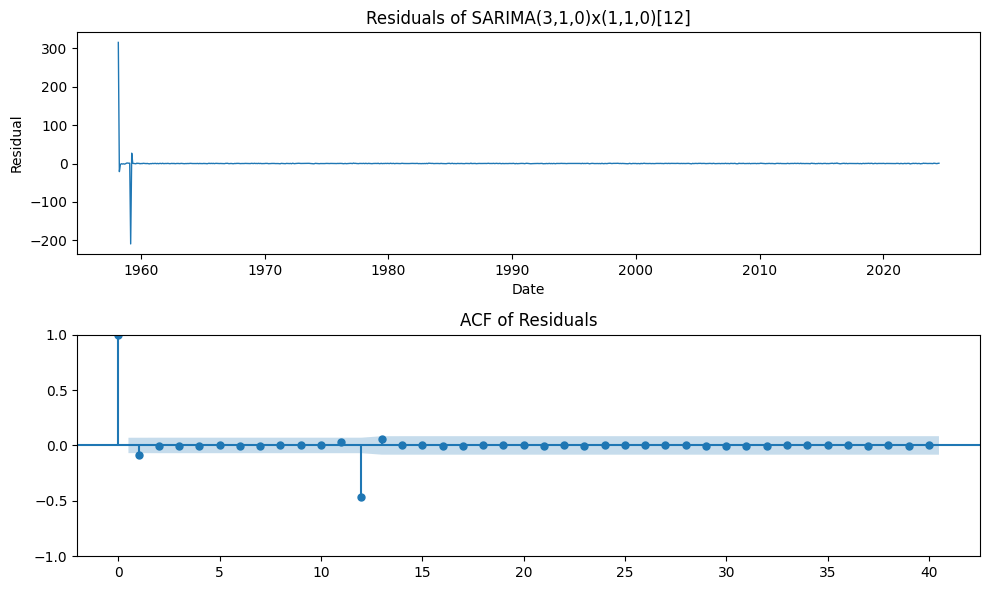

In [7]:
# --- Residual diagnostics (quick view) ---
resid = results.resid

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
ax[0].plot(resid, linewidth=1)
ax[0].set_title("Residuals of SARIMA(3,1,0)x(1,1,0)[12]")
ax[0].set_xlabel("Date")
ax[0].set_ylabel("Residual")

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(resid.dropna(), ax=ax[1], lags=40)
ax[1].set_title("ACF of Residuals")

plt.tight_layout()
plt.show()


In [8]:
# --- 12-month ahead forecast on original scale ---
# Last observed date
last_date = y.index[-1]

# Create forecast index (next 12 months)
forecast_index = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=24,
    freq="MS"
)

# Get forecast and 95% CI
forecast_res = results.get_forecast(steps=24)
mean_forecast = forecast_res.predicted_mean
conf_int = forecast_res.conf_int(alpha=0.05)  # 95% CI

mean_forecast.index = forecast_index
conf_int.index = forecast_index

print(mean_forecast)
print(conf_int)


2024-08-01    423.260731
2024-09-01    421.865259
2024-10-01    422.081683
2024-11-01    423.651763
2024-12-01    425.091487
2025-01-01    426.271195
2025-02-01    427.231494
2025-03-01    427.893251
2025-04-01    429.396337
2025-05-01    430.054822
2025-06-01    429.584412
2025-07-01    427.770871
2025-08-01    425.704328
2025-09-01    424.357474
2025-10-01    424.584523
2025-11-01    426.156952
2025-12-01    427.597144
2026-01-01    428.776769
2026-02-01    429.737720
2026-03-01    430.399617
2026-04-01    431.902408
2026-05-01    432.560679
2026-06-01    432.090651
2026-07-01    430.277471
Freq: MS, Name: predicted_mean, dtype: float64
            lower average  upper average
2024-08-01     422.647451     423.874010
2024-09-01     421.135054     422.595465
2024-10-01     421.272304     422.891063
2024-11-01     422.774311     424.529214
2024-12-01     424.151679     426.031294
2025-01-01     425.273083     427.269306
2025-02-01     426.178335     428.284654
2025-03-01     426.787789

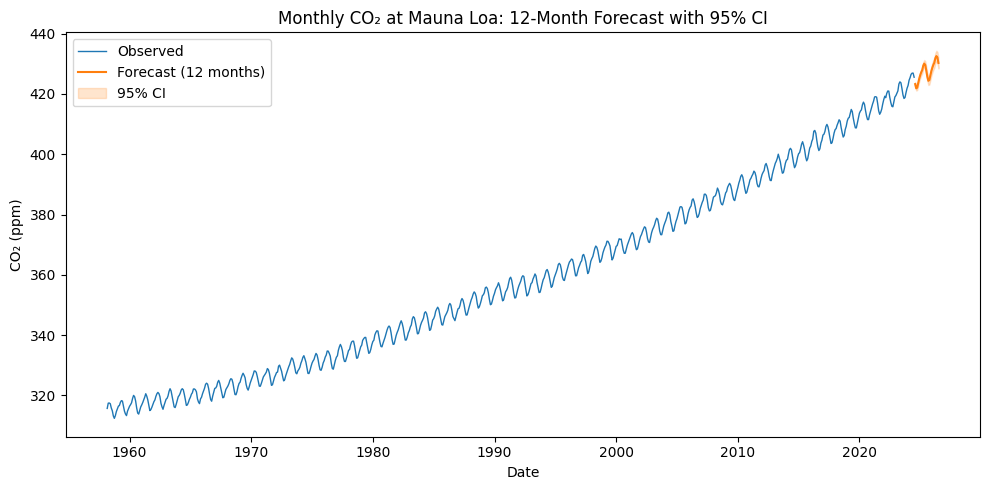

In [9]:
# --- Plot forecast vs raw series with 95% CI ---
plt.figure(figsize=(10, 5))

# Plot historical data
plt.plot(y, label="Observed", linewidth=1)

# Plot forecast
plt.plot(mean_forecast, label="Forecast (12 months)", color="C1")

# Plot confidence intervals
plt.fill_between(
    forecast_index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="C1",
    alpha=0.2,
    label="95% CI"
)

plt.title("Monthly CO₂ at Mauna Loa: 12-Month Forecast with 95% CI")
plt.xlabel("Date")
plt.ylabel("CO₂ (ppm)")
plt.legend()
plt.tight_layout()
plt.show()


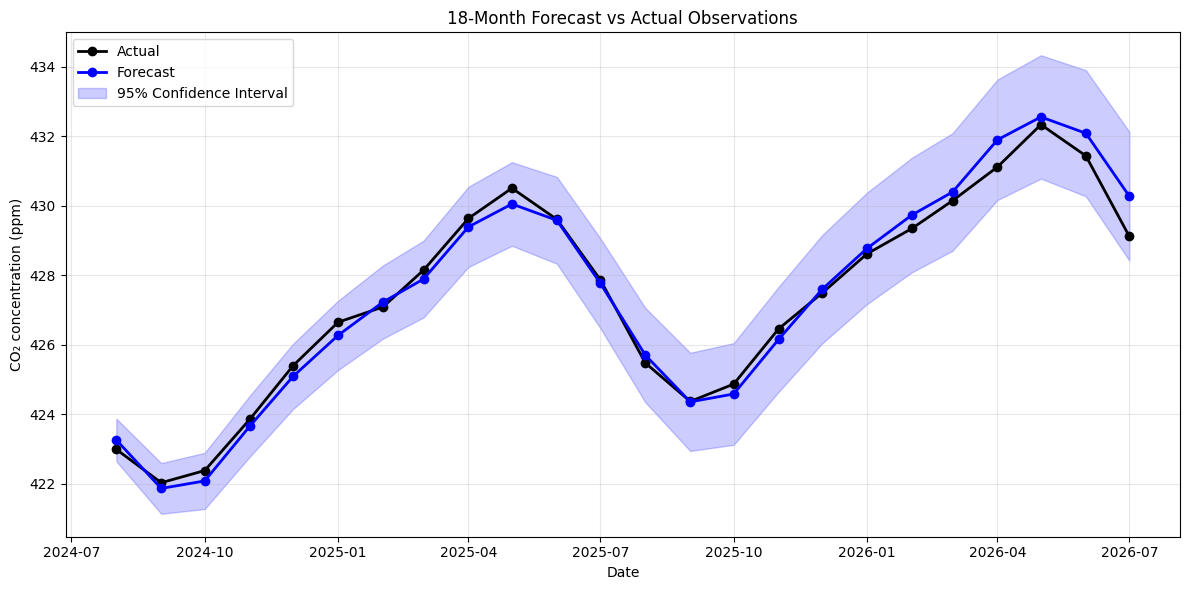

In [10]:
import matplotlib.pyplot as plt

# Actual values from the 18-month holdout period
actual = holdout["average"]

# Plot
plt.figure(figsize=(12, 6))

# Actual observed values
plt.plot(
    actual.index,
    actual,
    color="black",
    marker="o",
    linewidth=2,
    label="Actual"
)

# Forecast
plt.plot(
    mean_forecast.index,
    mean_forecast,
    color="blue",
    marker="o",
    linewidth=2,
    label="Forecast"
)

# 95% confidence interval
plt.fill_between(
    mean_forecast.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="blue",
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.xlabel("Date")
plt.ylabel("CO₂ concentration (ppm)")
plt.title("18-Month Forecast vs Actual Observations")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
from statsmodels.tsa.api import ExponentialSmoothing

model_triple = ExponentialSmoothing(
    train["average"], 
    seasonal_periods=12, 
    trend='add', 
    seasonal='add')

model_triple_fit = model_triple.fit()

In [20]:
forecast_triple = model_triple_fit.forecast(24)
print(forecast_triple)

2024-08-01    423.254670
2024-09-01    421.986435
2024-10-01    422.257875
2024-11-01    423.862820
2024-12-01    425.311840
2025-01-01    426.513323
2025-02-01    427.471348
2025-03-01    428.096802
2025-04-01    429.631510
2025-05-01    430.279984
2025-06-01    429.759875
2025-07-01    427.787962
2025-08-01    425.836612
2025-09-01    424.568377
2025-10-01    424.839817
2025-11-01    426.444762
2025-12-01    427.893782
2026-01-01    429.095265
2026-02-01    430.053291
2026-03-01    430.678744
2026-04-01    432.213452
2026-05-01    432.861927
2026-06-01    432.341817
2026-07-01    430.369904
Freq: MS, dtype: float64


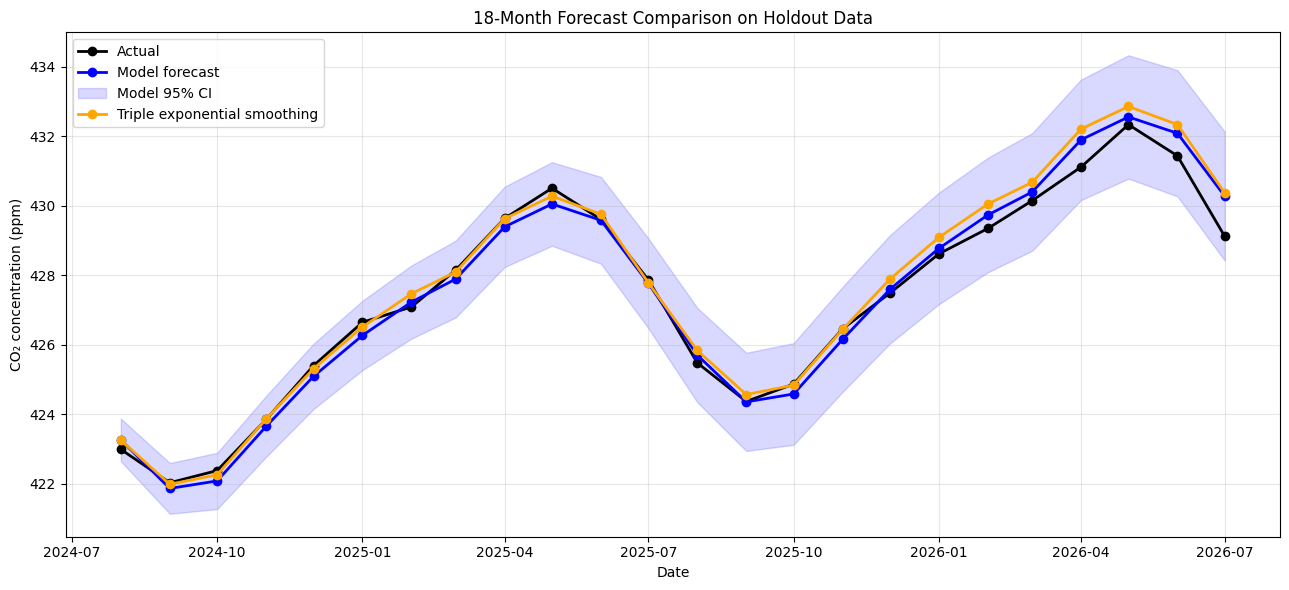

In [21]:
import matplotlib.pyplot as plt

# Actual observations in the 18-month holdout
actual = holdout["average"]

# Triple exponential smoothing forecast
forecast_triple = model_triple_fit.forecast(24)
forecast_triple.index = holdout.index

# Your other model's forecast
# Make sure its index also corresponds to the holdout period
mean_forecast.index = holdout.index
conf_int.index = holdout.index


# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(13, 6))

# Actual observed values
plt.plot(
    actual.index,
    actual,
    color="black",
    marker="o",
    linewidth=2,
    label="Actual"
)

# Model 1 forecast
plt.plot(
    mean_forecast.index,
    mean_forecast,
    color="blue",
    marker="o",
    linewidth=2,
    label="Model forecast"
)

# Model 1 95% CI
plt.fill_between(
    mean_forecast.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="blue",
    alpha=0.15,
    label="Model 95% CI"
)

# Triple exponential smoothing forecast
plt.plot(
    forecast_triple.index,
    forecast_triple,
    color="orange",
    marker="o",
    linewidth=2,
    label="Triple exponential smoothing"
)

plt.xlabel("Date")
plt.ylabel("CO₂ concentration (ppm)")
plt.title("18-Month Forecast Comparison on Holdout Data")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
comparison = pd.DataFrame({
    "Actual": holdout["average"],
    "Model_Forecast": mean_forecast,
    "Triple_Exp_Forecast": forecast_triple
})

print(comparison)

            Actual  Model_Forecast  Triple_Exp_Forecast
date                                                   
2024-08-01  422.99      423.260731           423.254670
2024-09-01  422.03      421.865259           421.986435
2024-10-01  422.38      422.081683           422.257875
2024-11-01  423.85      423.651763           423.862820
2024-12-01  425.40      425.091487           425.311840
2025-01-01  426.65      426.271195           426.513323
2025-02-01  427.09      427.231494           427.471348
2025-03-01  428.15      427.893251           428.096802
2025-04-01  429.64      429.396337           429.631510
2025-05-01  430.51      430.054822           430.279984
2025-06-01  429.61      429.584412           429.759875
2025-07-01  427.87      427.770871           427.787962
2025-08-01  425.48      425.704328           425.836612
2025-09-01  424.37      424.357474           424.568377
2025-10-01  424.87      424.584523           424.839817
2025-11-01  426.46      426.156952           426

In [23]:
comparison["Model_Error"] = (
    comparison["Actual"] - comparison["Model_Forecast"]
)

comparison["Triple_Error"] = (
    comparison["Actual"] - comparison["Triple_Exp_Forecast"]
)

print(comparison)

            Actual  Model_Forecast  Triple_Exp_Forecast  Model_Error  \
date                                                                   
2024-08-01  422.99      423.260731           423.254670    -0.270731   
2024-09-01  422.03      421.865259           421.986435     0.164741   
2024-10-01  422.38      422.081683           422.257875     0.298317   
2024-11-01  423.85      423.651763           423.862820     0.198237   
2024-12-01  425.40      425.091487           425.311840     0.308513   
2025-01-01  426.65      426.271195           426.513323     0.378805   
2025-02-01  427.09      427.231494           427.471348    -0.141494   
2025-03-01  428.15      427.893251           428.096802     0.256749   
2025-04-01  429.64      429.396337           429.631510     0.243663   
2025-05-01  430.51      430.054822           430.279984     0.455178   
2025-06-01  429.61      429.584412           429.759875     0.025588   
2025-07-01  427.87      427.770871           427.787962     0.09

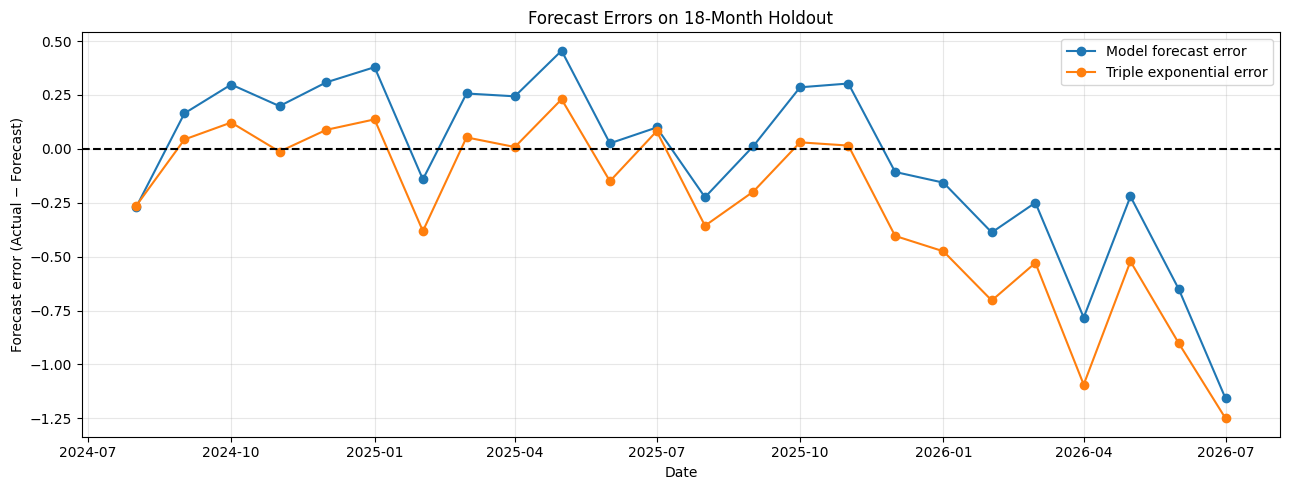

In [24]:
plt.figure(figsize=(13, 5))

plt.plot(
    comparison.index,
    comparison["Model_Error"],
    marker="o",
    label="Model forecast error"
)

plt.plot(
    comparison.index,
    comparison["Triple_Error"],
    marker="o",
    label="Triple exponential error"
)

plt.axhline(0, color="black", linestyle="--")

plt.ylabel("Forecast error (Actual − Forecast)")
plt.xlabel("Date")
plt.title("Forecast Errors on 18-Month Holdout")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import mean_absolute_error

mae_model = mean_absolute_error(
    comparison["Actual"],
    comparison["Model_Forecast"]
)

mae_triple = mean_absolute_error(
    comparison["Actual"],
    comparison["Triple_Exp_Forecast"]
)

print("Model MAE:", mae_model)
print("Triple exponential MAE:", mae_triple)

Model MAE: 0.30745765214220455
Triple exponential MAE: 0.33548224650475805


In [18]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_model = np.sqrt(
    mean_squared_error(
        comparison["Actual"],
        comparison["Model_Forecast"]
    )
)

rmse_triple = np.sqrt(
    mean_squared_error(
        comparison["Actual"],
        comparison["Triple_Exp_Forecast"]
    )
)

print("Model RMSE:", rmse_model)
print("Triple exponential RMSE:", rmse_triple)

Model RMSE: 0.394061811149464
Triple exponential RMSE: 0.4795075898160414


In [20]:
from statsmodels.tsa.api import SimpleExpSmoothing
model = SimpleExpSmoothing(df["average"])
model_single_fit = model.fit()

In [21]:
forecast_single = model_single_fit.forecast(12)
print(forecast_single)

2026-08-01    429.12
2026-09-01    429.12
2026-10-01    429.12
2026-11-01    429.12
2026-12-01    429.12
2027-01-01    429.12
2027-02-01    429.12
2027-03-01    429.12
2027-04-01    429.12
2027-05-01    429.12
2027-06-01    429.12
2027-07-01    429.12
Freq: MS, dtype: float64


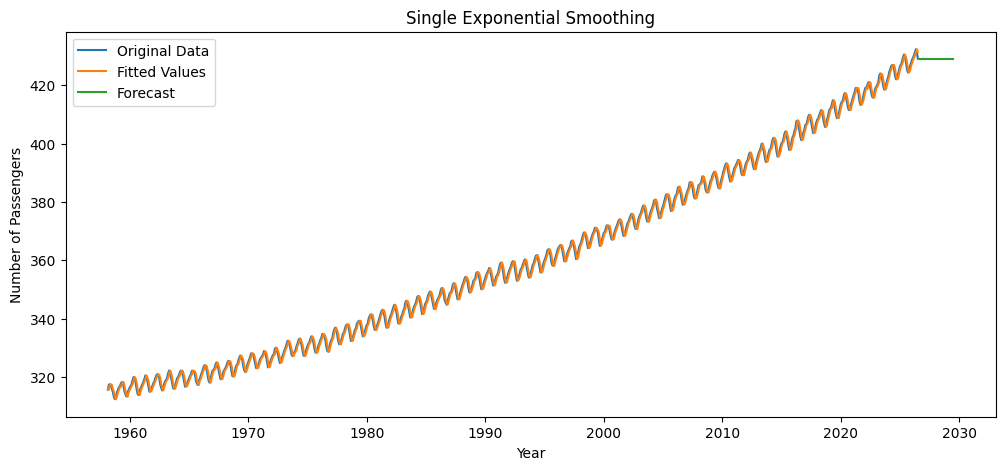

In [22]:
plt.figure(figsize=(12,5))
forecast_single = model_single_fit.forecast(36)
plt.plot(df["average"], label='Original Data')
plt.plot(model_single_fit.fittedvalues, label='Fitted Values')
plt.plot(forecast_single, label='Forecast')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.title('Single Exponential Smoothing')
plt.legend()
plt.show()

In [23]:
from statsmodels.tsa.api import Holt

model_double = Holt(df["average"])
model_double_fit = model_double.fit()

In [24]:
forecast_double = model_double_fit.forecast(12)
print(forecast_double)

2026-08-01    426.80
2026-09-01    424.48
2026-10-01    422.16
2026-11-01    419.84
2026-12-01    417.52
2027-01-01    415.20
2027-02-01    412.88
2027-03-01    410.56
2027-04-01    408.24
2027-05-01    405.92
2027-06-01    403.60
2027-07-01    401.28
Freq: MS, dtype: float64


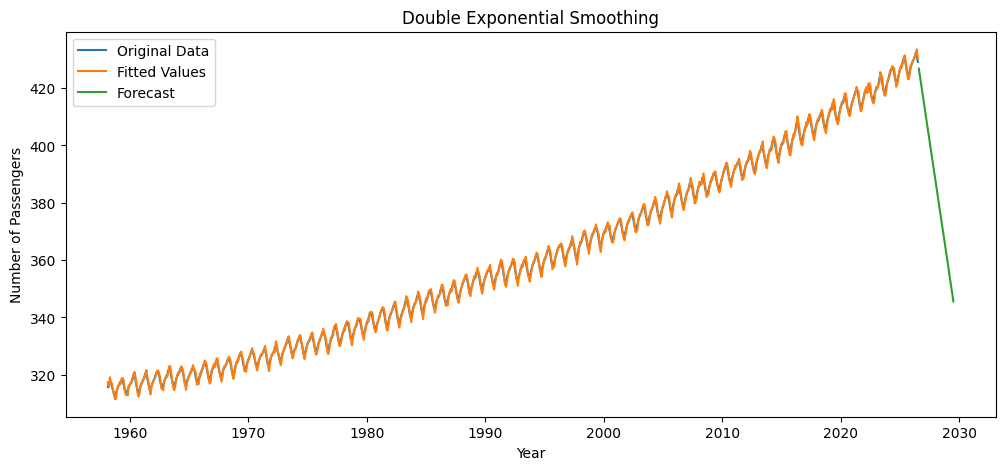

In [25]:
plt.figure(figsize=(12,5))
forecast_double = model_double_fit.forecast(36)
plt.plot(df["average"], label='Original Data')
plt.plot(model_double_fit.fittedvalues, label='Fitted Values')
plt.plot(forecast_double, label='Forecast')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.title('Double Exponential Smoothing')
plt.legend()
plt.show()

In [26]:
from statsmodels.tsa.api import ExponentialSmoothing

model_triple = ExponentialSmoothing(
    df["average"], 
    seasonal_periods=12, 
    trend='add', 
    seasonal='add')

model_triple_fit = model_triple.fit()

In [27]:
forecast_triple = model_triple_fit.forecast(12)
print(forecast_triple)

2026-08-01    427.245421
2026-09-01    426.040908
2026-10-01    426.321364
2026-11-01    427.875346
2026-12-01    429.272051
2027-01-01    430.474813
2027-02-01    431.353165
2027-03-01    432.066552
2027-04-01    433.512020
2027-05-01    434.255626
2027-06-01    433.612020
2027-07-01    431.759897
Freq: MS, dtype: float64


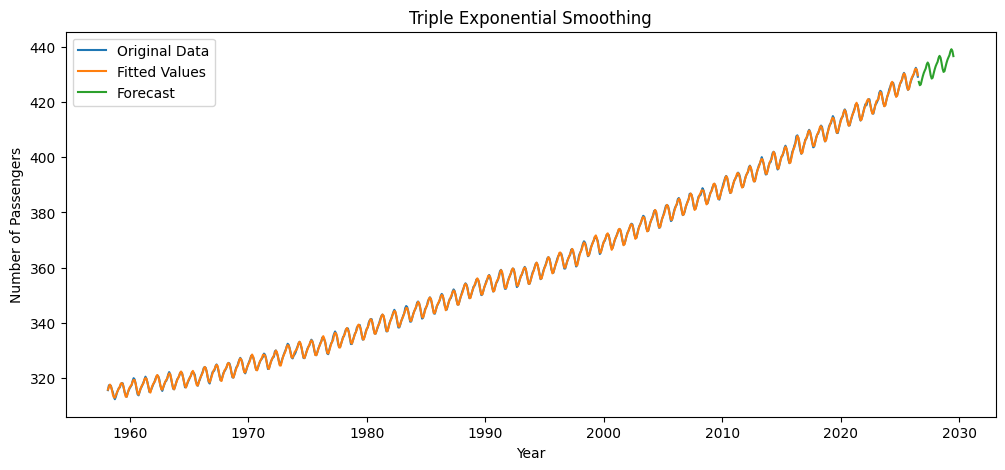

In [28]:
plt.figure(figsize=(12,5))
forecast_triple = model_triple_fit.forecast(36)
plt.plot(df["average"], label='Original Data')
plt.plot(model_triple_fit.fittedvalues, label='Fitted Values')
plt.plot(forecast_triple, label='Forecast')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.title('Triple Exponential Smoothing')
plt.legend()
plt.show()

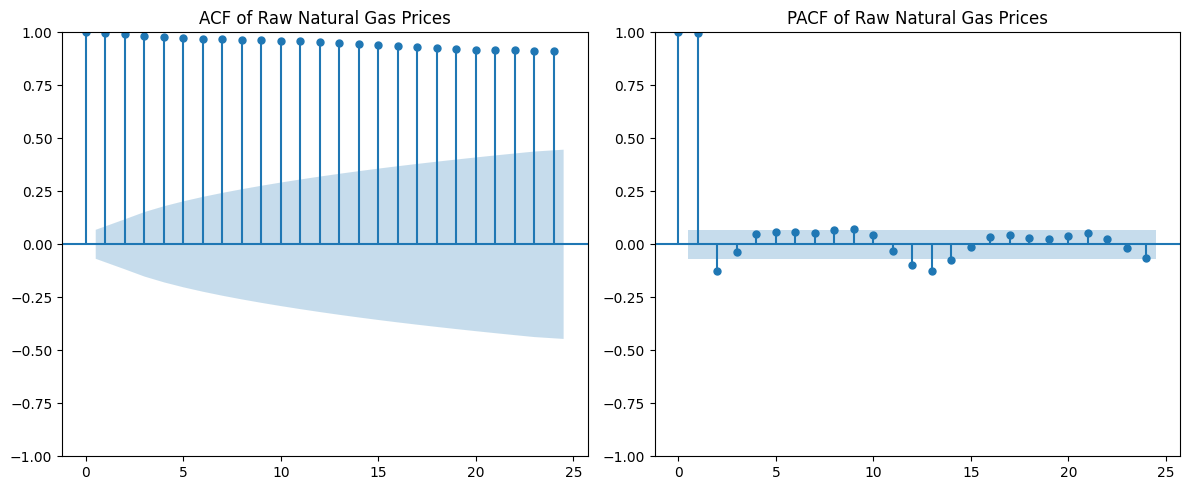

In [29]:
# Step 3: We plot the ACF and PACF of the raw monthly series

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Extract the raw price series
prices = df["average"]

# Create ACF and PACF plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ACF
plot_acf(prices, lags=24, ax=axes[0])
axes[0].set_title("ACF of Raw Natural Gas Prices")

# PACF
plot_pacf(prices, lags=24, ax=axes[1], method='ywm')
axes[1].set_title("PACF of Raw Natural Gas Prices")

plt.tight_layout()
plt.show()

In [30]:
# Step 4: ADF test & KPSS test of raw series

from statsmodels.tsa.stattools import adfuller, kpss

# Augmented Dickey-Fuller Test
adf_result = adfuller(prices)

print("Augmented Dickey-Fuller (ADF) Test")
print("----------------------------------")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")
print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

# KPSS Test
kpss_result = kpss(prices, regression='c', nlags='auto')

print("\n\nKPSS Test")
print("----------------")
print(f"KPSS Statistic : {kpss_result[0]:.4f}")
print(f"p-value        : {kpss_result[1]:.4f}")
print(f"Lags Used      : {kpss_result[2]}")
print("\nCritical Values:")
for key, value in kpss_result[3].items():
    print(f"   {key}: {value:.4f}")

Augmented Dickey-Fuller (ADF) Test
----------------------------------
ADF Statistic : 5.9076
p-value       : 1.0000
Lags Used     : 21
Observations  : 799

Critical Values:
   1%: -3.4386
   5%: -2.8652
   10%: -2.5687


KPSS Test
----------------
KPSS Statistic : 4.3471
p-value        : 0.0100
Lags Used      : 18

Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


/var/folders/qy/441jwthx2_1g0zy86by2glkh0000gn/T/ipykernel_4594/3379213664.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(prices, regression='c', nlags='auto')


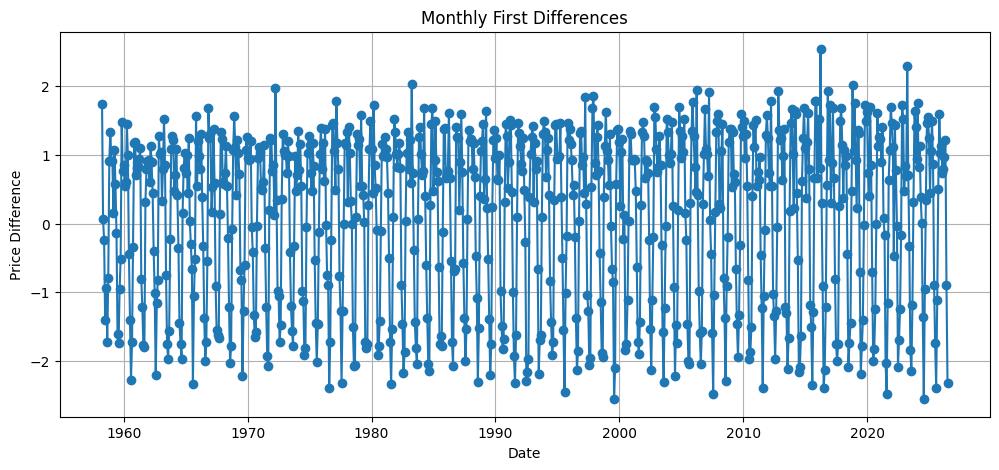

In [33]:
# First difference of the natural gas settlement prices

df['Difference'] = df['average'].diff()

natgas_diff = df.dropna()

plt.figure(figsize=(12,5))
plt.plot(natgas_diff['Difference'], marker='o')
plt.title("Monthly First Differences")
plt.xlabel("Date")
plt.ylabel("Price Difference")
plt.grid(True)
plt.show()

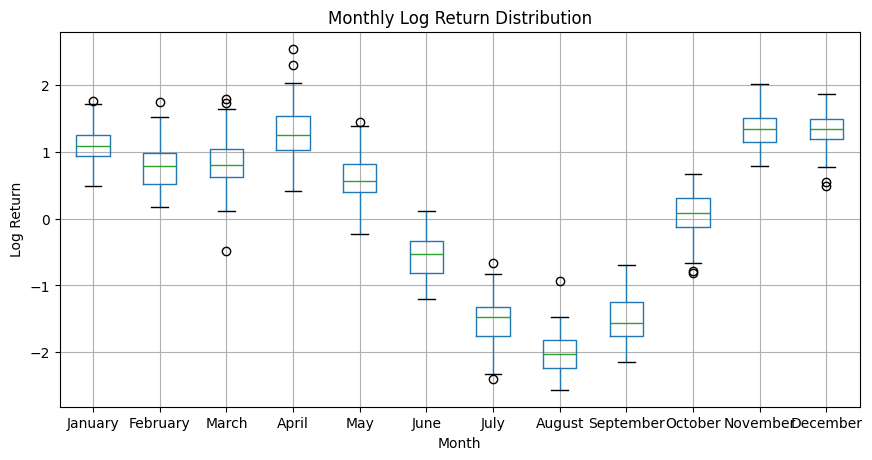

In [34]:
import calendar

# Ordered list of month names
month_order = list(calendar.month_name[1:])   # ['January', 'February', ..., 'December']

natgas_diff = df.dropna().copy()
natgas_diff.loc[:, 'Month'] = natgas_diff.index.month_name()

# Convert Month column to ordered categorical
natgas_diff['Month'] = pd.Categorical(
    natgas_diff['Month'],
    categories=month_order,
    ordered=True
)

fig, ax = plt.subplots(figsize=(10,5))
natgas_diff.boxplot(column='Difference', by='Month', ax=ax)
ax.set_title("Monthly Log Return Distribution")
plt.suptitle("")
ax.set_xlabel("Month")
ax.set_ylabel("Log Return")
ax.grid(True)
plt.show()


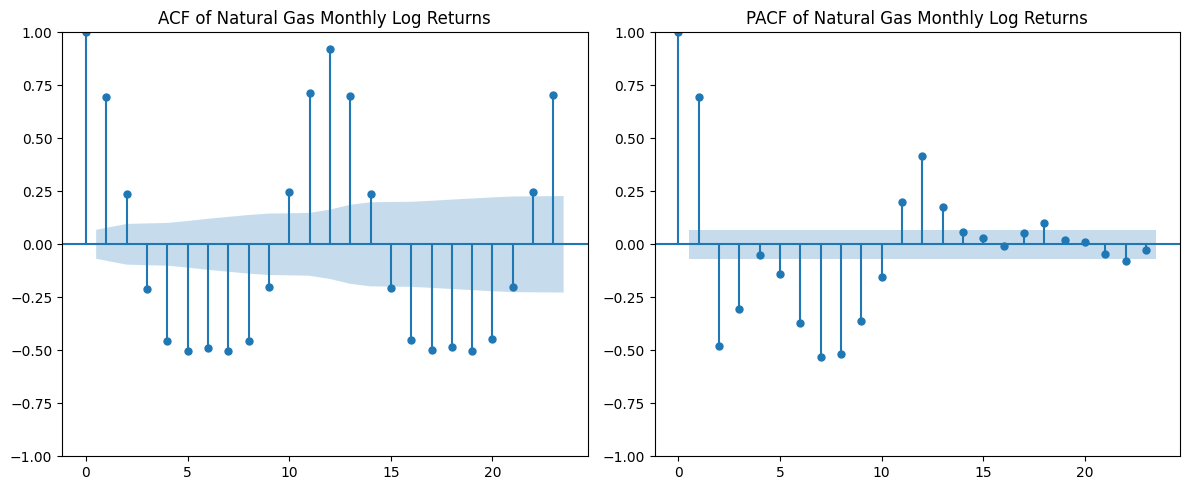

In [35]:
# ACF & PACF of natural gas monthly log returns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Extract the raw price series
prices2 = natgas_diff['Difference']

# Create ACF and PACF plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ACF
plot_acf(prices2, lags=23, ax=axes[0]) # upto lag 23
axes[0].set_title("ACF of Natural Gas Monthly Log Returns")

# PACF
plot_pacf(prices2, lags=23, ax=axes[1], method='ywm')
axes[1].set_title("PACF of Natural Gas Monthly Log Returns")

plt.tight_layout()
plt.show()

In [36]:
# ADF test & KPSS test of monthly log returns

from statsmodels.tsa.stattools import adfuller, kpss

# Extract the price series
prices2 = natgas_diff['Difference']

# Augmented Dickey-Fuller Test
adf_result = adfuller(prices2)

print("Augmented Dickey-Fuller (ADF) Test")
print("----------------------------------")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")
print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

# KPSS Test
kpss_result = kpss(prices2, regression='c', nlags='auto')

print("\n\nKPSS Test")
print("----------------")
print(f"KPSS Statistic : {kpss_result[0]:.4f}")
print(f"p-value        : {kpss_result[1]:.4f}")
print(f"Lags Used      : {kpss_result[2]}")
print("\nCritical Values:")
for key, value in kpss_result[3].items():
    print(f"   {key}: {value:.4f}")

Augmented Dickey-Fuller (ADF) Test
----------------------------------
ADF Statistic : -5.6658
p-value       : 0.0000
Lags Used     : 21
Observations  : 798

Critical Values:
   1%: -3.4386
   5%: -2.8652
   10%: -2.5687


KPSS Test
----------------
KPSS Statistic : 0.2101
p-value        : 0.1000
Lags Used      : 15

Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


/var/folders/qy/441jwthx2_1g0zy86by2glkh0000gn/T/ipykernel_4594/1930024524.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(prices2, regression='c', nlags='auto')


In [11]:
import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm

from itertools import product
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")

# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("co2_mm_mlo.csv")

df["date"] = pd.to_datetime(
    df[["year", "month"]].assign(day=1)
)

df = df.set_index("date")
df = df.asfreq("MS")

# Use only the CO2 series
y = df["average"].dropna()

print(y.head())
print(f"\nNumber of observations: {len(y)}")


# ============================================================
# 2. SEARCH SPACE
# ============================================================

p_values = range(0, 6)
d_values = range(0, 3)
q_values = range(0, 6)

P_values = range(0, 4)
D_values = range(0, 2)
Q_values = range(0, 4)

seasonal_period = 12


# ============================================================
# 3. EXHAUSTIVE SEARCH
# ============================================================

results = []

total_models = (
    len(p_values)
    * len(d_values)
    * len(q_values)
    * len(P_values)
    * len(D_values)
    * len(Q_values)
)

print(f"\nTotal models to evaluate: {total_models}")


for p, d, q, P, D, Q in product(
    p_values,
    d_values,
    q_values,
    P_values,
    D_values,
    Q_values
):

    order = (p, d, q)
    seasonal_order = (P, D, Q, seasonal_period)

    try:

        model = sm.tsa.statespace.SARIMAX(
            y,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted = model.fit(
            disp=False,
            maxiter=200
        )

        # ----------------------------------------------------
        # Information criteria
        # ----------------------------------------------------

        aic = fitted.aic
        bic = fitted.bic
        hqic = fitted.hqic

        # AICc
        n = fitted.nobs
        k = len(fitted.params)

        if n - k - 1 > 0:
            aicc = (
                aic
                + (2 * k * (k + 1)) / (n - k - 1)
            )
        else:
            aicc = np.nan

        # ----------------------------------------------------
        # Residuals
        # ----------------------------------------------------

        residuals = fitted.resid.dropna()

        # Ljung-Box at several important lags
        lb = acorr_ljungbox(
            residuals,
            lags=[12, 24, 36],
            return_df=True
        )

        lb_p_12 = lb.loc[12, "lb_pvalue"]
        lb_p_24 = lb.loc[24, "lb_pvalue"]
        lb_p_36 = lb.loc[36, "lb_pvalue"]

        # ----------------------------------------------------
        # Store results
        # ----------------------------------------------------

        results.append({

            "order": order,
            "seasonal_order": seasonal_order,

            "p": p,
            "d": d,
            "q": q,

            "P": P,
            "D": D,
            "Q": Q,

            "AIC": aic,
            "AICc": aicc,
            "BIC": bic,
            "HQIC": hqic,

            "LB_p_12": lb_p_12,
            "LB_p_24": lb_p_24,
            "LB_p_36": lb_p_36,

            "converged": fitted.mle_retvals.get(
                "converged",
                True
            ),

            "loglik": fitted.llf,
            "n_params": k

        })

    except Exception as e:

        # Keep track of failed models
        results.append({

            "order": order,
            "seasonal_order": seasonal_order,

            "p": p,
            "d": d,
            "q": q,

            "P": P,
            "D": D,
            "Q": Q,

            "AIC": np.nan,
            "AICc": np.nan,
            "BIC": np.nan,
            "HQIC": np.nan,

            "LB_p_12": np.nan,
            "LB_p_24": np.nan,
            "LB_p_36": np.nan,

            "converged": False,

            "loglik": np.nan,
            "n_params": np.nan
        })


# ============================================================
# 4. CREATE RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(results)

print("\nSearch completed.")

print(
    f"Successful models: "
    f"{results_df['AIC'].notna().sum()}"
)

print(
    f"Failed models: "
    f"{results_df['AIC'].isna().sum()}"
)


date
1958-03-01    315.71
1958-04-01    317.45
1958-05-01    317.51
1958-06-01    317.27
1958-07-01    315.87
Freq: MS, Name: average, dtype: float64

Number of observations: 821

Total models to evaluate: 3456


KeyboardInterrupt: 

In [12]:
best_bic = (
    results_df
    .dropna(subset=["BIC"])
    .sort_values("BIC")
)

print(
    best_bic[
        [
            "order",
            "seasonal_order",
            "AIC",
            "AICc",
            "BIC",
            "HQIC",
            "LB_p_12",
            "LB_p_24",
            "LB_p_36"
        ]
    ].head(20)
)


NameError: name 'results_df' is not defined

In [13]:
best_aic = (
    results_df
    .dropna(subset=["AIC"])
    .sort_values("AIC")
)

print(best_aic.head(20))


NameError: name 'results_df' is not defined

In [ ]:
valid_models = results_df[
    (results_df["AIC"].notna()) &
    (results_df["converged"]) &
    (results_df["LB_p_12"] > 0.05) &
    (results_df["LB_p_24"] > 0.05) &
    (results_df["LB_p_36"] > 0.05)
].copy()

print(
    f"Models passing residual diagnostics: "
    f"{len(valid_models)}"
)


In [ ]:
valid_models = valid_models.sort_values(
    ["BIC", "AICc"]
)

print(
    valid_models[
        [
            "order",
            "seasonal_order",
            "AIC",
            "AICc",
            "BIC",
            "HQIC",
            "LB_p_12",
            "LB_p_24",
            "LB_p_36"
        ]
    ].head(20)
)


In [ ]:
best = valid_models.iloc[0]

best_order = best["order"]
best_seasonal_order = best["seasonal_order"]

print("Best model:")
print("Order:", best_order)
print("Seasonal order:", best_seasonal_order)


In [ ]:
final_model = sm.tsa.statespace.SARIMAX(
    y,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_results = final_model.fit(disp=False)

print(final_results.summary())


and only after all computation finishes do you perform the selection.
That's ideal because parallel workers never decide which model is best. They simply evaluate candidates.

The master process makes the final decision.

That separation is important for robustness.

And I would save the results
For a long exhaustive run, definitely save the complete search:

Later you can change your selection criteria without refitting 6,912 models.

You can estimate it very accurately while it's running
Your current code doesn't show progress, but you can modify the loop to print timing.

In [ ]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import statsmodels.api as sm


In [ ]:
import warnings
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm

from itertools import product
from joblib import Parallel, delayed
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")


# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("co2_mm_mlo.csv")

df["date"] = pd.to_datetime(
    df[["year", "month"]].assign(day=1)
)

df = df.set_index("date")
df = df.asfreq("MS")

y = df["average"].dropna()

print(y.head())
print(f"\nNumber of observations: {len(y)}")


# ============================================================
# 2. SEARCH SPACE
# ============================================================

p_values = range(0, 6)
d_values = range(0, 3)
q_values = range(0, 6)

P_values = range(0, 4)
D_values = range(0, 2)
Q_values = range(0, 4)

seasonal_period = 12


# ============================================================
# 3. CREATE MODEL CONFIGURATIONS
# ============================================================

model_configs = list(
    product(
        p_values,
        d_values,
        q_values,
        P_values,
        D_values,
        Q_values
    )
)

print(f"\nTotal models: {len(model_configs)}")


# ============================================================
# 4. FUNCTION FOR ONE SARIMA MODEL
# ============================================================

def fit_one_model(config):

    p, d, q, P, D, Q = config

    order = (p, d, q)
    seasonal_order = (
        P,
        D,
        Q,
        seasonal_period
    )

    base_result = {
        "order": order,
        "seasonal_order": seasonal_order,

        "p": p,
        "d": d,
        "q": q,

        "P": P,
        "D": D,
        "Q": Q,
    }

    try:

        model = sm.tsa.statespace.SARIMAX(
            y,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted = model.fit(
            disp=False,
            maxiter=200
        )

        # ----------------------------------------------------
        # Check convergence
        # ----------------------------------------------------

        converged = fitted.mle_retvals.get(
            "converged",
            True
        )

        # ----------------------------------------------------
        # Information criteria
        # ----------------------------------------------------

        aic = fitted.aic
        bic = fitted.bic
        hqic = fitted.hqic

        n = fitted.nobs
        k = len(fitted.params)

        if n - k - 1 > 0:

            aicc = (
                aic
                + (2 * k * (k + 1))
                / (n - k - 1)
            )

        else:

            aicc = np.nan

        # ----------------------------------------------------
        # Residual diagnostics
        # ----------------------------------------------------

        residuals = fitted.resid.dropna()

        lb = acorr_ljungbox(
            residuals,
            lags=[12, 24, 36],
            return_df=True
        )

        # ----------------------------------------------------
        # Return result
        # ----------------------------------------------------

        return {
            **base_result,

            "AIC": aic,
            "AICc": aicc,
            "BIC": bic,
            "HQIC": hqic,

            "LB_p_12": lb.loc[12, "lb_pvalue"],
            "LB_p_24": lb.loc[24, "lb_pvalue"],
            "LB_p_36": lb.loc[36, "lb_pvalue"],

            "converged": converged,

            "loglik": fitted.llf,
            "n_params": k,

            "error": None
        }

    except Exception as e:

        return {
            **base_result,

            "AIC": np.nan,
            "AICc": np.nan,
            "BIC": np.nan,
            "HQIC": np.nan,

            "LB_p_12": np.nan,
            "LB_p_24": np.nan,
            "LB_p_36": np.nan,

            "converged": False,

            "loglik": np.nan,
            "n_params": np.nan,

            "error": str(e)
        }


# ============================================================
# 5. PARALLEL SEARCH
# ============================================================

n_cores = os.cpu_count()

print(f"\nCPU cores available: {n_cores}")

results = Parallel(
    n_jobs=-1,
    backend="loky",
    verbose=10
)(
    delayed(fit_one_model)(config)
    for config in model_configs
)


# ============================================================
# 6. RESULTS
# ============================================================

results_df = pd.DataFrame(results)

print("\nSearch completed.")

print(
    "Successful:",
    results_df["AIC"].notna().sum()
)

print(
    "Failed:",
    results_df["AIC"].isna().sum()
)
